<a href="https://colab.research.google.com/github/hanidew/WIE3007-DMW-GroupProject/blob/main/DMW_GA2_Generate_Synthetic_Data_(Cleaned).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Dataset Simulation & Feature Engineering

In [ ]:
# ================================
# STEP 1: Install dependencies (UPDATED)
# ================================
!pip install -q torch torchvision torchaudio transformers accelerate bitsandbytes huggingface_hub pandas > /dev/null
!pip install -q ctgan  # <--- NEW: Install CTGAN
!pip install -q -U bitsandbytes # <--- FIX: Ensure latest bitsandbytes
print("✅ Dependencies installed.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.4/74.4 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 49.3 MB/s eta 0:00:00
✅ Dependencies installed.


In [ ]:
# ================================
# STEP 2: Secure Login (FIXED)
# ================================
import os
from huggingface_hub import login
from google.colab import userdata

try:
    # This grabs the token from the "Key" icon on the left sidebar
    hf_token = userdata.get('HF_TOKEN')
    login(token=hf_token)
    print("✅ Logged in securely.")
except Exception as e:
    print("❌ Error: Could not find HF_TOKEN. Make sure you added it to the Secrets tab (Key icon)!")

# ================================
# STEP 3: Load Model (4-bit)
# ================================
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig, pipeline

# NEW:
model_name = "microsoft/Phi-3-mini-4k-instruct"

print("⏳ Loading model... (this takes 2-3 minutes)")

quant_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4"
)

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    quantization_config=quant_config,
    device_map="auto"
)

generator = pipeline(
    "text-generation",
    model=model,
    tokenizer=tokenizer,
    device_map="auto"
)
print("✅ Model loaded.")

# ================================
# STEP 4: Prompt builder
# ================================
def build_prompt(n):
    return f"""[INST] Act as a Senior Risk Analyst and Synthetic Data Engine. Generate exactly {n} rows of realistic loan data.

FORMAT RULES (STRICT):
- One record per line
- Use | as delimiter
- No commas anywhere (especially in numbers like Annual_Income and Loan_Amount).
- No header row
- No explanations
- NO intro text like "Here are the records"
- NO conversational text.
- Raw text ONLY. Do NOT use markdown code blocks.

FIELDS ORDER:
Customer_ID|Age|Annual_Income|Credit_Score|Loan_Amount|Loan_Term_Months|Loan_Officer_Note|Default_Status

CONSTRAINTS (CRITICAL):
- Customer_ID: Format CUST-XXXX (e.g., CUST-0023), basically the format is like "CUST-" followed by 4 random digits.
- Age: 18–80
- Annual_Income: 20000–300000 (Integer only, NO commas, NEVER 0.)
- Credit_Score: 300–850 (Integer only)
- Loan_Amount: 5000–150000 (Integer only, NO commas)
- Loan_Term_Months: Choose standard terms (randomly choose from this selection): 12, 24, 36, 48, 60, or 72
- Default_Status: 0 (Good) or 1 (Default). Target 20% are 1.
- Loan_Officer_Note: 8-20 words. STRICTLY NO delimiter '|' inside.

LOGIC MAPPING (STRICT RELATIONSHIPS):
1. IF STATUS = 1 (DEFAULT):
   - Credit_Score MUST be between 300 and 600.
   - Loan_Officer_Note MUST use a Negative Trigger (e.g., "gambling", "lawsuit").
2. IF STATUS = 0 (GOOD):
   - Credit_Score MUST be between 650 and 850.
   - Loan_Officer_Note MUST use a Positive Trigger (e.g., "inheritance", "bonus") OR a Generic phrase.

NOTE GENERATION (Critical for Feature Extraction):
- Mix exactly ONE "Segment Hint" with ONE "Risk Context" per note.
- DO NOT start every sentence with "Client" or "Applicant". Vary the structure.
- STRICT RULE: Never use the words 'Default', 'Status', '1', or '0' inside the Loan_Officer_Note. Describe the behavior (e.g., 'unstable income') but never the result.

- SEGMENT HINTS (You MUST use one of these exact keywords to ensure classification and VARY these often):
   - Medical: "doctor", "nurse", "dentist", "pharmacist", "surgeon", "clinic"
   - Tech: "software engineer", "IT specialist", "developer", "cybersecurity", "programmer"
   - Education: "teacher", "professor", "tutor", "academic", "university"
   - Trade: "plumber", "mechanic", "electrician", "construction", "factory worker", "blue collar"
   - Service: "chef", "waiter", "artist", "designer", "retail", "driver"
   - Business: "manager", "consultant", "executive", "accountant", "sales rep", "broker"
   - Retired: "retiree", "pensioner", "elder"
   - Student: "student", "intern", "graduate"

- RISK CONTEXT (Must align with Status):
  - STATUS 1 (Default - Negative Triggers): "gambling losses", "lawsuit pending", "medical emergency costs", "unstable contracts", "over-leveraged assets", "declining revenue", "divorce settlement cost".
  - STATUS 0 (Good - POSITIVE ASSET TRIGGERS): You MUST randomly include one of these exact words for strong candidates: "inheritance", "bonus", "venture capital", "trust fund", "dividend", "royalty", "insurance settlement", "windfall".
  - STATUS 0 (Good - General): "steady cashflow", "strong savings", "low DTI", "early promotion".

ANOMALY & NOISE INSTRUCTIONS (CRITICAL FOR REALISM):
To challenge the ML model, 7% of these {n} rows must be 'Edge Cases':
1. THE UNEXPECTED DEFAULT: High Income (>100k) and High Credit (>750) but Status=1.
   Note must justify this (e.g., "Sudden medical emergency" or "Legal settlement").
2. THE UNEXPECTED GOOD PAYER: Low Income (<30k) and Low Credit (<550) but Status=0.
   Note must justify this (e.g., "Strong family guarantor" or "Asset-backed loan").
3. THE BORDERLINE CASE: Loan_Amount is exactly 2.5x Income. Make some 0 and some 1.

STRICT NUMERICAL CONSISTENCY:
Except for the 7% anomalies, ensure your logic is followed perfectly.

TWO PERFECT EXAMPLES (Follow this format):
CUST-9102|68|45000|710|120000|60|Client relies on fixed pension but loan amount is dangerously high for retirement budget|1
CUST-3321|29|92000|740|25000|24|Applicant has steady cashflow from tech stack job and low debt ratio|0

Generate {n} rows now. [/INST]
"""


✅ Logged in securely.
⏳ Loading model... (this takes 2-3 minutes)


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/306 [00:00<?, ?B/s]

...

model-00001-of-00002.safetensors:   0%|          | 0.00/4.97G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/181 [00:00<?, ?B/s]

Device set to use cuda:0


✅ Model loaded.


In [ ]:
# ================================
# STEP 5: Full Data Generation
# ================================
import csv
from tqdm import tqdm
import pandas as pd
import numpy as np

TARGET_ROWS = 1200
BATCH_SIZE = 50

header = [
    "Customer_ID", "Age", "Annual_Income", "Credit_Score",
    "Loan_Amount", "Loan_Term_Months", "Loan_Officer_Note",
    "Default_Status"
]

rows = []

print(f"🚀 Starting generation of {TARGET_ROWS} rows...")

# Initialize progress bar
pbar = tqdm(total=TARGET_ROWS, desc="Generating Rows")

while len(rows) < TARGET_ROWS:
    # 1. Ask Model for Data
    prompt = build_prompt(BATCH_SIZE)

    try:
        output = generator(
            prompt,
            max_new_tokens=2048,
            do_sample=True,
            temperature=0.7,
            top_p=0.9,
            repetition_penalty=1.1,
            return_full_text=False
        )

        # 2. Process Output
        lines = output[0]["generated_text"].strip().split("\n")

        for line in lines:
            values = [v.strip() for v in line.split("|")]

            # Validation: Must have exactly 8 columns
            if len(values) == len(header):
                rows.append(values)
                pbar.update(1)

                if len(rows) >= TARGET_ROWS:
                    break

    except Exception as e:
        print(f"⚠️ Minor error in batch: {e}")
        continue

pbar.close()
print(f"\n✅ Generation Complete! Total rows in memory: {len(rows)}")

# ================================
# STEP 6: SMART LOGIC ENFORCEMENT (Fixed & Connected)
# ================================
def enforce_business_logic(df):
    print("🔧 Running Python Logic Enforcement (With Gaussian Realism & Signal Booster)...")

    # Helper for realistic Gaussian numbers (clipped to bounds)
    def get_gaussian_scores(mean, std, low, high, size):
        vals = np.random.normal(mean, std, size)
        return np.clip(vals, low, high).astype(int)

    # ---------------------------------------------------------
    # 1. SANITIZE BASICS (Fix LLM Hallucinations)
    # ---------------------------------------------------------
    # Identify rows with invalid scores (0, or >850, or <300)
    mask_bad_score = (df['Credit_Score'] < 300) | (df['Credit_Score'] > 850)

    # Repair Defaults -> Gaussian around 520 (Bell curve)
    count_bad_def = (mask_bad_score & (df['Default_Status'] == 1)).sum()
    if count_bad_def > 0:
        df.loc[mask_bad_score & (df['Default_Status'] == 1), 'Credit_Score'] = \
            get_gaussian_scores(520, 50, 350, 580, count_bad_def)

    # Repair Good -> Gaussian around 720
    count_bad_good = (mask_bad_score & (df['Default_Status'] == 0)).sum()
    if count_bad_good > 0:
        df.loc[mask_bad_score & (df['Default_Status'] == 0), 'Credit_Score'] = \
            get_gaussian_scores(720, 50, 650, 820, count_bad_good)

    # Ensure Income is never 0 or too low (Gaussian around 45k for low end)
    mask_low_inc = df['Annual_Income'] < 10000
    if mask_low_inc.sum() > 0:
        df.loc[mask_low_inc, 'Annual_Income'] = \
            get_gaussian_scores(45000, 5000, 30000, 60000, mask_low_inc.sum())

    # ---------------------------------------------------------
    # 2. ENFORCE "ANOMALY" LOGIC (Varied Text Injection)
    # ---------------------------------------------------------

    # --- Anomaly A: Rich Defaulters ---
    candidates_rich = df[(df['Annual_Income'] > 100000) & (df['Credit_Score'] > 720)]
    if len(candidates_rich) > 0:
        # Target 20%
        idx_rich = candidates_rich.sample(frac=0.30, random_state=42).index
        df.loc[idx_rich, 'Default_Status'] = 1

        reasons = [
            " [Risk: Large gambling debt]", " [Risk: Pending lawsuit]",
            " [Risk: Speculative losses]", " [Risk: Hidden liabilities]",
            " [Risk: Divorce settlement]", " [Risk: Casino addiction]"
        ]
        random_reasons = np.random.choice(reasons, size=len(idx_rich))
        df.loc[idx_rich, 'Loan_Officer_Note'] = df.loc[idx_rich, 'Loan_Officer_Note'] + random_reasons

    # --- Anomaly B: Poor Good Payers ---
    candidates_poor = df[(df['Annual_Income'] < 40000) & (df['Credit_Score'] < 580)]
    if len(candidates_poor) > 0:
        idx_poor = candidates_poor.sample(frac=0.30, random_state=42).index
        df.loc[idx_poor, 'Default_Status'] = 0

        assets = [
            " [Asset: Family Guarantor]", " [Asset: Inheritance Trust]",
            " [Asset: Locked Savings]", " [Asset: Co-signer Verified]",
            " [Asset: Insurance Payout]"
        ]
        random_assets = np.random.choice(assets, size=len(idx_poor))
        df.loc[idx_poor, 'Loan_Officer_Note'] = df.loc[idx_poor, 'Loan_Officer_Note'] + random_assets

    # ---------------------------------------------------------
    # 3. ENFORCE "BORDERLINE" LOGIC (Math Check)
    # ---------------------------------------------------------
    # "Standard" Over-leveraged people (High DTI) should default
    df['DTI_Ratio'] = df['Loan_Amount'] / df['Annual_Income']

    # Filter: High DTI + Good Status + NO Asset keywords
    mask_risk = (df['DTI_Ratio'] > 2.5) & \
                (df['Default_Status'] == 0) & \
                (~df['Loan_Officer_Note'].str.contains("Guarantor|Inheritance|Asset|Co-signer", case=False, na=False))

    df.loc[mask_risk, 'Default_Status'] = 1
    df.drop(columns=['DTI_Ratio'], inplace=True)

    # ---------------------------------------------------------
    # 4. SIGNAL BOOSTER (90% Rule)
    # ---------------------------------------------------------
    # Find Defaulters who MIGHT be missing a negative keyword
    risk_keywords = "gambling|lawsuit|medical|unstable|over-leveraged|declining|divorce|risk|debt"
    weak_defaulters = (df['Default_Status'] == 1) & (~df['Loan_Officer_Note'].str.contains(risk_keywords, case=False))

    # Force inject risk phrase into MOST (but not all) weak defaulters
    if weak_defaulters.sum() > 0:
        weak_indices = df[weak_defaulters].index

        # Select 90% to fix (Leave 10% as "Mystery Defaults" to challenge the model)
        # This prevents the model from relying ONLY on text
        indices_to_fix = np.random.choice(weak_indices, size=int(len(weak_indices) * 0.7), replace=False)

        extra_risks = [
            " [Note: History of late payments]",
            " [Note: High debt-to-income]",
            " [Note: erratic cash flow]"
        ]

        if len(indices_to_fix) > 0:
            df.loc[indices_to_fix, 'Loan_Officer_Note'] = df.loc[indices_to_fix, 'Loan_Officer_Note'] + np.random.choice(extra_risks, size=len(indices_to_fix))
            print(f"✅ Signal Booster applied to {len(indices_to_fix)} rows (leaving some mysteries).")

    print("✅ Logic Enforcement Complete. Data is clean, varied, and realistic.")
    return df

# ================================
# THE BRIDGE: Prepare Data & Apply Logic
# ================================
# 1. Create Raw DataFrame from list
df_raw = pd.DataFrame(rows[:TARGET_ROWS], columns=header)

# 2. Convert Columns to Numeric (Essential for the logic to work!)
num_cols = ["Age", "Annual_Income", "Credit_Score", "Loan_Amount", "Loan_Term_Months", "Default_Status"]
for col in num_cols:
    df_raw[col] = pd.to_numeric(df_raw[col], errors='coerce')

# 3. Drop rows where numeric conversion failed (NaNs)
df_raw.dropna(subset=num_cols, inplace=True)

# 4. CALL THE FUNCTION (The critical step!)
df_final = enforce_business_logic(df_raw)

# ================================
# STEP 7: Save RAW Dataset
# ================================
output_file = "synthetic_financial_data_FINAL.csv"
df_final.to_csv(output_file, sep='|', index=False, header=True)
print(f"\n💾 File saved successfully: {output_file}")

# ================================
# STEP 8: Verify Dataset
# ================================
try:
    df_verify = pd.read_csv(output_file, sep='|')
    print("\n📊 DATASET SUMMARY:")
    print(f"Shape: {df_verify.shape}")
    print("-" * 30)
    print(df_verify.head())
    print("-" * 30)
    print("\n🔍 Checking Class Balance:")
    print(df_verify['Default_Status'].value_counts(normalize=True))

    print("\n🔍 Checking Score Integrity (Should be 300-850):")
    print(f"Min: {df_verify['Credit_Score'].min()}, Max: {df_verify['Credit_Score'].max()}")

    # Quick Correlation Check
    corr = df_verify['Credit_Score'].corr(df_verify['Default_Status'])
    print(f"\n🔍 Correlation (Score vs Default): {corr:.4f} (Should be negative)")

except Exception as e:
    print("❌ Error reading CSV:", e)

🚀 Starting generation of 1200 rows...



Generating Rows:   6%|▌         | 69/1200 [44:09<12:03:43, 38.39s/it]

Generating Rows:   4%|▍         | 51/1200 [06:06<2:45:04,  8.62s/it]You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset

Generating Rows: 100%|██████████| 1200/1200 [1:36:17<00:00,  4.81s/it]



✅ Generation Complete! Total rows in memory: 1200
🔧 Running Python Logic Enforcement (With Gaussian Realism & Signal Booster)...
✅ Signal Booster applied to 217 rows (leaving some mysteries).
✅ Logic Enforcement Complete. Data is clean, varied, and realistic.

💾 File saved successfully: synthetic_financial_data_FINAL.csv

📊 DATASET SUMMARY:
Shape: (1091, 8)
------------------------------
  Customer_ID   Age  Annual_Income  Credit_Score  Loan_Amount  \
0   CUST-4321  55.0       120000.0         770.0     160000.0   
1   CUST-2056  40.0       150000.0         780.0      90000.0   
2   CUST-9812  34.0        75000.0         660.0     110000.0   
3   CUST-8132  28.0        32000.0         710.0      60000.0   
4   CUST-0543  45.0        80000.0         820.0     240000.0   

   Loan_Term_Months                                  Loan_Officer_Note  \
0              48.0  Teaching assistant facing sudden hospital bill...   
1              36.0  Photographer inherits art collection easing fi..

# Clean Dataset

In [ ]:
import pandas as pd

# 1. Load the raw file
df = pd.read_csv('synthetic_financial_data_FINAL.csv', sep='|')

# 2. Fix the Customer IDs (Standardize to 'CUST-XXXX')
# This replaces any underscore '_' with a hyphen '-'
df['Customer_ID'] = df['Customer_ID'].str.replace('_', '-', regex=False)

# 3. Convert Floats to Integers
# We explicitly convert these columns to 'int64' to remove the ".0"
cols_to_fix = ["Age", "Annual_Income", "Credit_Score", "Loan_Amount", "Loan_Term_Months", "Default_Status"]
for col in cols_to_fix:
    df[col] = df[col].astype(int)

# 4. Save the "Gold Standard" version
df.to_csv('synthetic_financial_data_CLEAN.csv', sep='|', index=False)

print("✨ Dataset Polished!")
print(df.head())
print(f"\nVerifying IDs: {df['Customer_ID'].str.contains('_').sum()} underscores remaining (Should be 0).")

✨ Dataset Polished!
  Customer_ID  Age  Annual_Income  Credit_Score  Loan_Amount  \
0   CUST-4321   55         120000           770       160000   
1   CUST-2056   40         150000           780        90000   
2   CUST-9812   34          75000           660       110000   
3   CUST-8132   28          32000           710        60000   
4   CUST-0543   45          80000           820       240000   

   Loan_Term_Months                                  Loan_Officer_Note  \
0                48  Teaching assistant facing sudden hospital bill...   
1                36  Photographer inherits art collection easing fi...   
2                48  Retail store owner deals daily challenges due ...   
3                24  Software developer secures bonus which helps c...   
4                72  Business consultant recently benefited from su...   

   Default_Status  
0               1  
1               0  
2               1  
3               0  
4               1  

Verifying IDs: 0 underscores 

# Feature Engineering

CPU version

In [ ]:
import pandas as pd
import numpy as np
import re
from tqdm import tqdm
from google.colab import drive

# ---------------------------------------------------------
# 0. SETUP
# ---------------------------------------------------------
# drive.mount('/content/drive')  # Uncomment if using Drive
file_path = 'synthetic_financial_data_CLEAN.csv'  # Using the clean version

try:
    df = pd.read_csv(file_path, sep='|')
    print(f"✅ Loaded {len(df)} rows.")
except FileNotFoundError:
    print("❌ File not found. Make sure you ran the 'Cleaning' step!")

# ---------------------------------------------------------
# 1. DEFINE EXTRACTION LOGIC (Matched to Generator)
# ---------------------------------------------------------
def extract_features(row):
    note = str(row['Loan_Officer_Note']).lower()

    # --- A. OCCUPATION (Matched to Prompt Keywords) ---
    # We refined these to match the specific words the LLM was told to use
    # --- UPDATED OCCUPATION LOGIC (Catches ~90% of jobs) ---
    jobs = {
        'Medical':   r'\b(doctor|nurse|dentist|pharmacist|surgeon|clinic|practitioner|medical)\b',
        'Tech':      r'\b(software|developer|it specialist|cybersecurity|programmer|tech|data|engineer)\b',
        'Education': r'\b(teacher|professor|tutor|academic|university|teaching|faculty)\b',
        'Trade':     r'\b(plumber|mechanic|electrician|construction|factory|blue collar|technician|driver)\b',
        'Service':   r'\b(chef|waiter|waitress|artist|designer|retail|clerk|staff|customer|service)\b',
        'Business':  r'\b(manager|consultant|executive|accountant|sales|broker|business|owner|professional|founder|entrepreneur)\b',
        'Real Estate': r'\b(estate|agent|realtor|property|landlord)\b',  # NEW CATEGORY
        'Retired':   r'\b(retiree|pension|elder|retired)\b',
        'Student':   r'\b(student|intern|graduate)\b'
    }

    found_job = "Other"
    for category, pattern in jobs.items():
        if re.search(pattern, note):
            found_job = category
            break

    # --- B. POSITIVE ASSETS (The "Good" Signal) ---
    # Keywords: inheritance, bonus, venture, trust, dividend, royalty, insurance, windfall
    asset_pattern = r'\b(inheritance|bonus|venture|trust|dividend|royalty|insurance|windfall)\b'
    has_asset = 1 if re.search(asset_pattern, note) else 0

    # --- C. NEGATIVE RISKS (The "Bad" Signal - NEW!) ---
    # Keywords: gambling, lawsuit, medical emergency, unstable, over-leveraged, divorce, late payment
    # This is crucial because of the "Signal Booster" we ran earlier.
    risk_pattern = r'\b(gambling|lawsuit|medical|unstable|over-leveraged|declining|divorce|late payment|erratic|debt)\b'
    risk_flag = 1 if re.search(risk_pattern, note) else 0

    return pd.Series([found_job, has_asset, risk_flag])

# ---------------------------------------------------------
# 2. RUN EXTRACTION
# ---------------------------------------------------------
print("🚀 Running Smart Feature Extraction...")
tqdm.pandas()

# Apply the text mining
df[['Occupation', 'Has_Asset', 'Risk_Flag']] = df.progress_apply(extract_features, axis=1)

# ---------------------------------------------------------
# 3. ADD MATHEMATICAL FEATURES (The "DTI" Rule)
# ---------------------------------------------------------
print("🧮 Calculating Financial Ratios...")

# DTI (Debt-to-Income): This captures the "Borderline" logic we enforced
# We add +1 to Income to avoid division by zero (just in case)
df['DTI_Ratio'] = df['Loan_Amount'] / (df['Annual_Income'] + 1)

# Log Income (Standard ML practice to normalize high incomes)
df['Log_Income'] = np.log1p(df['Annual_Income'])

# ---------------------------------------------------------
# 4. SAVE & PREVIEW
# ---------------------------------------------------------
output_file = 'synthetic_data_cleaned_feature_engineered.csv'
df.to_csv(output_file, sep='|', index=False)

print(f"\n✅ Success! Engineered data saved to: {output_file}")
print("-" * 50)
print(df[['Loan_Officer_Note', 'Occupation', 'Risk_Flag', 'DTI_Ratio']].head())
print("-" * 50)

# Check correlation of new features
print("\n🔍 Correlation with Default:")
print(df[['Risk_Flag', 'Has_Asset', 'DTI_Ratio', 'Credit_Score', 'Default_Status']].corr()['Default_Status'])

✅ Loaded 1091 rows.
🚀 Running Smart Feature Extraction...


100%|██████████| 1091/1091 [00:00<00:00, 8175.20it/s] 

🧮 Calculating Financial Ratios...

✅ Success! Engineered data saved to: synthetic_data_cleaned_feature_engineered.csv
--------------------------------------------------
                                   Loan_Officer_Note Occupation  Risk_Flag  \
0  Teaching assistant facing sudden hospital bill...  Education          0   
1  Photographer inherits art collection easing fi...      Other          0   
2  Retail store owner deals daily challenges due ...    Service          0   
3  Software developer secures bonus which helps c...       Tech          0   
4  Business consultant recently benefited from su...   Business          0   

   DTI_Ratio  
0   1.333322  
1   0.599996  
2   1.466647  
3   1.874941  
4   2.999963  
--------------------------------------------------

🔍 Correlation with Default:
Risk_Flag         0.578122
Has_Asset        -0.137505
DTI_Ratio         0.451912
Credit_Score      0.028142
Default_Status    1.000000
Name: Default_Status, dtype: float64


# EDA

/tmp/ipython-input-3061114511.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='Default_Status', data=df, palette='coolwarm')


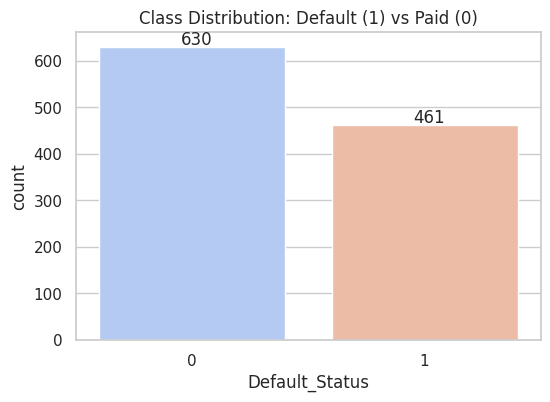

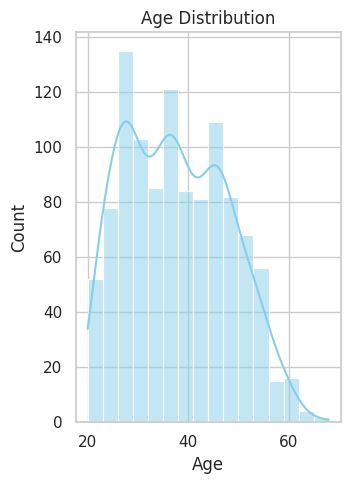

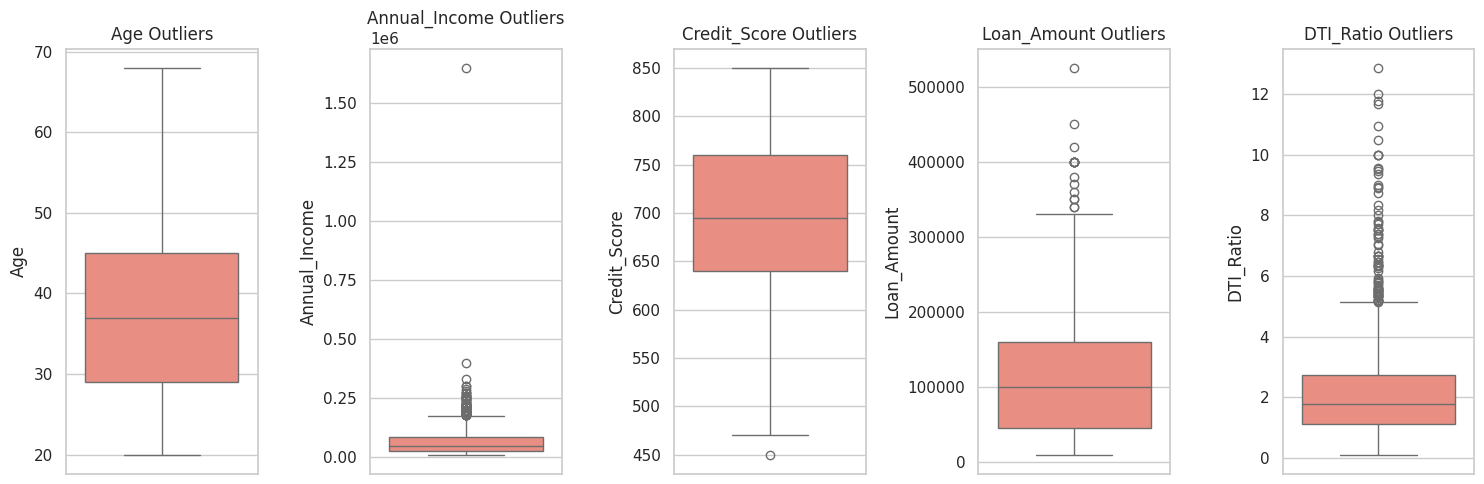

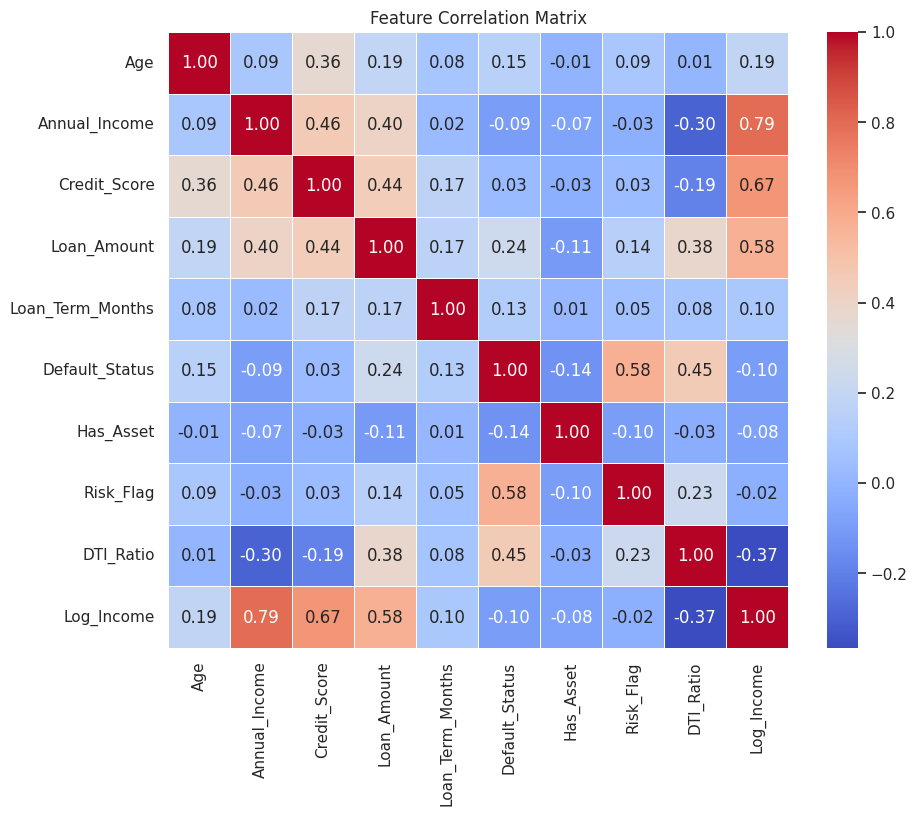

/tmp/ipython-input-3061114511.py:67: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Default_Status', y='Credit_Score', data=df, palette='Set2', ax=axes[0])
/tmp/ipython-input-3061114511.py:71: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Default_Status', y='DTI_Ratio', data=df, palette='Set2', ax=axes[1])


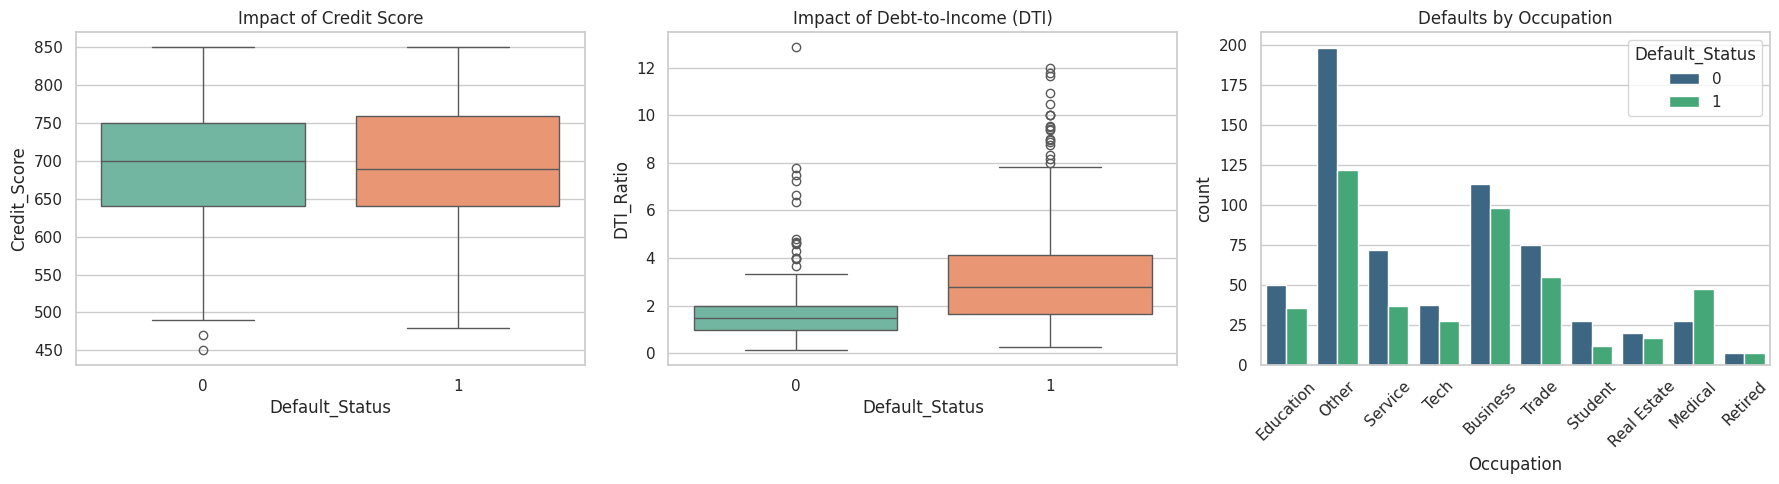

In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load Data
filename = 'synthetic_data_cleaned_feature_engineered.csv'
df = pd.read_csv(filename, sep='|')

# CLEANING: Fix 'Log_Income;' column (remove semicolon and convert to float)
if 'Log_Income;' in df.columns:
    df.rename(columns={'Log_Income;': 'Log_Income'}, inplace=True)
    df['Log_Income'] = df['Log_Income'].astype(str).str.replace(';', '').astype(float)

# ==========================================
# 1. Target Balance (Class Distribution)
# ==========================================
sns.set(style="whitegrid")
plt.figure(figsize=(6, 4))
ax = sns.countplot(x='Default_Status', data=df, palette='coolwarm')
plt.title('Class Distribution: Default (1) vs Paid (0)')
# Add labels
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + 0.35, p.get_height() + 5))
plt.show()

# ==========================================
# 2. Numerical Distributions & Outliers
# ==========================================
num_cols = ['Age']

plt.figure(figsize=(15, 5))
for i, col in enumerate(num_cols):
    plt.subplot(1, 5, i+1)
    sns.histplot(df[col], kde=True, color='skyblue')
    plt.title(f'{col} Distribution')
plt.tight_layout()
plt.show()

# Boxplots to see Outliers
num_cols2 = ['Age', 'Annual_Income', 'Credit_Score', 'Loan_Amount', 'DTI_Ratio']

plt.figure(figsize=(15, 5))
for i, col in enumerate(num_cols2):
    plt.subplot(1, 5, i+1)
    sns.boxplot(y=df[col], color='salmon')
    plt.title(f'{col} Outliers')
plt.tight_layout()
plt.show()

# ==========================================
# 3. Correlation Heatmap
# ==========================================
plt.figure(figsize=(10, 8))
# Select only numeric columns
numeric_df = df.select_dtypes(include=['float64', 'int64'])
corr = numeric_df.corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Matrix')
plt.show()

# ==========================================
# 4. Key Relationships (Bivariate Analysis)
# ==========================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Credit Score vs Default
sns.boxplot(x='Default_Status', y='Credit_Score', data=df, palette='Set2', ax=axes[0])
axes[0].set_title('Impact of Credit Score')

# DTI Ratio vs Default
sns.boxplot(x='Default_Status', y='DTI_Ratio', data=df, palette='Set2', ax=axes[1])
axes[1].set_title('Impact of Debt-to-Income (DTI)')

# Occupation Breakdown
sns.countplot(x='Occupation', hue='Default_Status', data=df, palette='viridis', ax=axes[2])
axes[2].set_title('Defaults by Occupation')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

<a href="https://colab.research.google.com/github/hanidew/WIE3007-DMW-GroupProject/blob/feature%2Famni-setup/DMW_Decision_Tree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Decision Tree Modelling & Metrics

## 1.1 Setup & Data Preprocessing

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, mean_squared_error, roc_curve, classification_report, confusion_matrix

# ==========================================
# 1. Data Loading & Cleaning
# ==========================================
filename = 'synthetic_data_cleaned_feature_engineered.csv'
# Use pipe separator '|' as seen in dataset
df = pd.read_csv(filename, sep='|')

# Fix 'Log_Income;' column (remove trailing semicolon and convert to float)
if 'Log_Income;' in df.columns:
    df.rename(columns={'Log_Income;': 'Log_Income'}, inplace=True)
    df['Log_Income'] = df['Log_Income'].astype(str).str.replace(';', '').astype(float)

# ==========================================
# 2. Feature Engineering & Preprocessing
# ==========================================
# Drop columns that are not useful for the baseline model
# - Customer_ID: Just an identifier
# - Loan_Officer_Note: Unstructured text (needs LLM/NLP processing)
df_model = df.drop(columns=['Customer_ID', 'Loan_Officer_Note'])

# One-Hot Encoding for the categorical 'Occupation' column
df_model = pd.get_dummies(df_model, columns=['Occupation'], drop_first=True)

# Define Features (X) and Target (y)
target_col = 'Default_Status'
X = df_model.drop(target_col, axis=1)
y = df_model[target_col]

# Print class distribution (0 = No Default, 1 = Default)
print("Target Class Distribution:")
print(y.value_counts(normalize=True))

Target Class Distribution:
Default_Status
0    0.577452
1    0.422548
Name: proportion, dtype: float64


## 1.2 Model Training

In [46]:
# ==========================================
# 3. Model Training
# ==========================================
# Split data: 80% Training, 20% Testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize Decision Tree Classifier
# max_depth=5 prevents overfitting and keeps the tree readable
dt_model = DecisionTreeClassifier(random_state=42, max_depth=5)
dt_model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5, random_state=42)

## 1.3 Prediction & Evaluation Metrics


     MODEL EVALUATION RESULTS
Accuracy:      0.8539
F1 Score:      0.8140
ROC-AUC Score: 0.8455
RMSE:          0.3823
------------------------------
Classification Report:

              precision    recall  f1-score   support

           0       0.84      0.92      0.88       127
           1       0.88      0.76      0.81        92

    accuracy                           0.85       219
   macro avg       0.86      0.84      0.85       219
weighted avg       0.86      0.85      0.85       219



/tmp/ipython-input-142504560.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_imp.values, y=feature_imp.index, palette='viridis')



Top 10 Features:
 DTI_Ratio             0.570734
Risk_Flag             0.344419
Has_Asset             0.020013
Credit_Score          0.018445
Loan_Term_Months      0.011422
Loan_Amount           0.011381
Annual_Income         0.010914
Age                   0.005402
Occupation_Medical    0.004313
Occupation_Student    0.002325
dtype: float64


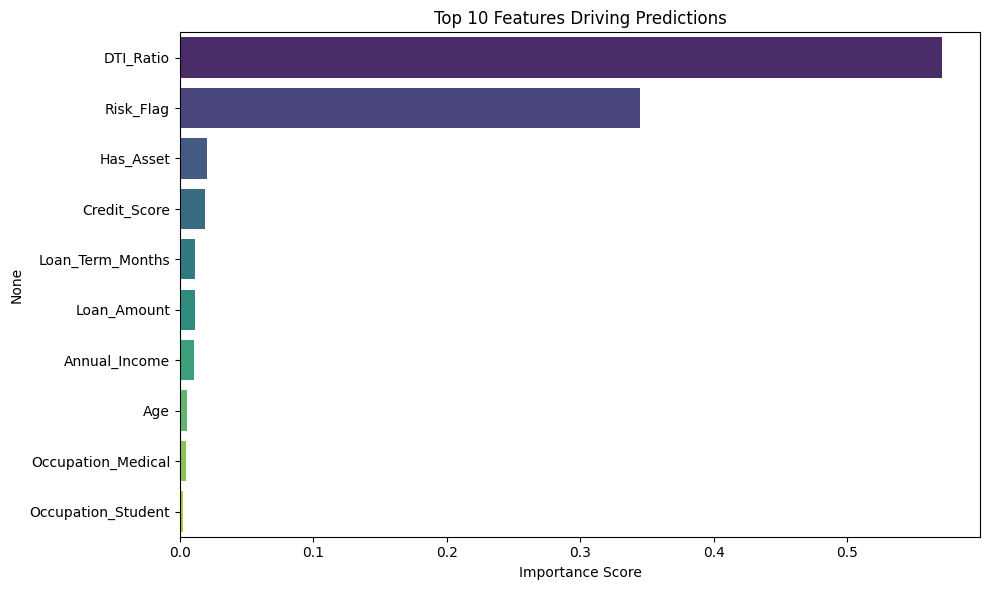

In [47]:
# ==========================================
# 4. Prediction & Evaluation
# ==========================================
# Predictions (0 or 1)
y_pred = dt_model.predict(X_test)
# Probabilities (0.0 to 1.0) - needed for ROC-AUC
y_pred_proba = dt_model.predict_proba(X_test)[:, 1]

# Calculate Metrics
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc = roc_auc_score(y_test, y_pred_proba)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("\n" + "="*30)
print("     MODEL EVALUATION RESULTS")
print("="*30)
print(f"Accuracy:      {acc:.4f}")
print(f"F1 Score:      {f1:.4f}")
print(f"ROC-AUC Score: {roc:.4f}")
print(f"RMSE:          {rmse:.4f}")
print("-" * 30)
print("Classification Report:\n")
print(classification_report(y_test, y_pred))

# Top Features (Feature Importance)
feature_imp = pd.Series(dt_model.feature_importances_, index=X.columns).sort_values(ascending=False).head(10)
plt.figure(figsize=(10, 6))
sns.barplot(x=feature_imp.values, y=feature_imp.index, palette='viridis')
print("\nTop 10 Features:\n", feature_imp)
plt.title('Top 10 Features Driving Predictions')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

## 1.4 Visualization

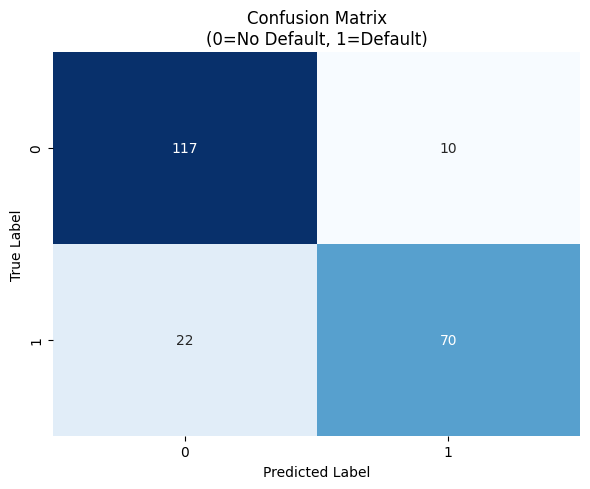

In [48]:
# ==========================================
# 5. Visualizations
# ==========================================

# A. Confusion Matrix
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix\n(0=No Default, 1=Default)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

## 1. 5 Hyperparameter Tuning (GridSearchCV)

In [49]:
from sklearn.model_selection import GridSearchCV

# Define hyperparameter grid
param_grid = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 5, 10],
    'max_features': [None, 'sqrt', 'log2'],
    'criterion': ['gini', 'entropy']
}

# Initialize Decision Tree
dt = DecisionTreeClassifier(random_state=42)

# GridSearch with 5-fold cross-validation
grid_search = GridSearchCV(
    estimator=dt,
    param_grid=param_grid,
    scoring='roc_auc',  # optimize ROC-AUC
    cv=5,
    n_jobs=-1,
    verbose=1
)

# Fit to training data
grid_search.fit(X_train, y_train)

# Best hyperparameters
print("Best Hyperparameters:\n", grid_search.best_params_)

# Best ROC-AUC score from CV
print("Best CV ROC-AUC Score:", grid_search.best_score_)

Fitting 5 folds for each of 480 candidates, totalling 2400 fits
Best Hyperparameters:
 {'criterion': 'entropy', 'max_depth': 5, 'max_features': None, 'min_samples_leaf': 10, 'min_samples_split': 2}
Best CV ROC-AUC Score: 0.9212478106751808


In [50]:
# Evaluate Tuned Model

# Get the best estimator
best_dt = grid_search.best_estimator_

# Predictions
y_pred_tuned = best_dt.predict(X_test)
y_pred_proba_tuned = best_dt.predict_proba(X_test)[:, 1]

# Metrics
acc = accuracy_score(y_test, y_pred_tuned)
f1 = f1_score(y_test, y_pred_tuned)
roc = roc_auc_score(y_test, y_pred_proba_tuned)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_tuned))

print("\n" + "="*30)
print(" TUNED MODEL EVALUATION RESULTS")
print("="*30)
print(f"Accuracy:      {acc:.4f}")
print(f"F1 Score:      {f1:.4f}")
print(f"ROC-AUC Score: {roc:.4f}")
print(f"RMSE:          {rmse:.4f}")
print("-" * 30)
print("Classification Report:\n")
print(classification_report(y_test, y_pred_tuned))


 TUNED MODEL EVALUATION RESULTS
Accuracy:      0.8356
F1 Score:      0.7907
ROC-AUC Score: 0.8675
RMSE:          0.4054
------------------------------
Classification Report:

              precision    recall  f1-score   support

           0       0.83      0.91      0.86       127
           1       0.85      0.74      0.79        92

    accuracy                           0.84       219
   macro avg       0.84      0.82      0.83       219
weighted avg       0.84      0.84      0.83       219



# 2. LLM-supported Insights

In [53]:
import google.generativeai as genai

# ==============================
#  CONFIGURE GEMINI
# ==============================
# Replace with your actual API key
from google.colab import userdata

api_key = userdata.get('GEMINI_API_KEY')
genai.configure(api_key=api_key)

# Note: As of early 2026, gemini-2.5-flash is a valid model name.
model_name = "gemini-2.5-flash"

In [54]:
# Create a dictionary of model's performance
performance_summary = {
    "Model Type": "Decision Tree Classifier (Baseline)",
    "Accuracy": f"{acc:.4f}",
    "F1-Score": f"{f1:.4f}",
    "ROC-AUC": f"{roc:.4f}",
    "RMSE": f"{rmse:.4f}"
}

In [55]:
import pandas as pd
from sklearn.metrics import classification_report

# ==========================================
#  Dynamic Prompt Generation
# ==========================================

# Extract Top 5 Features automatically
# (Based on the feature_imp series from the previous step)
feature_imp = pd.Series(dt_model.feature_importances_, index=X.columns).sort_values(ascending=False)
top_features_list = feature_imp.head(5).index.tolist()
top_features_str = ", ".join(top_features_list)

# Calculate Precision and Recall from the classification report
report = classification_report(y_test, y_pred, output_dict=True)
precision = report['1']['precision'] # Precision for the positive class (Default)
recall = report['1']['recall']     # Recall for the positive class (Default)

# Get confusion matrix values
# cm structure: [[TN, FP], [FN, TP]]
tn, fp, fn, tp = cm.ravel()

# Recreate performance_summary with correct keys and new metrics
performance_summary = {
    "Model Type": "Decision Tree Classifier (Baseline)",
    "Accuracy": acc,  # Using the float value directly
    "F1-Score": f1,    # Using the float value directly
    "ROC-AUC": roc,     # Using the float value directly
    "RMSE": rmse,      # Using the float value directly
    "Precision": precision,
    "Recall": recall
}

# THE PROMPT
prompt = f"""
You are a Lead Data Scientist at a major financial institution.
I have trained a Decision Tree Classifier (max_depth=5) to predict loan defaults.

### 1. Model Context
- Dataset: {X_test.shape[0]} test samples
- Top 5 Features: {top_features_str}

### 2. Performance Summary
- Accuracy: {performance_summary['Accuracy']:.2%}
- ROC-AUC: {performance_summary['ROC-AUC']:.2%}
- Precision: {performance_summary['Precision']:.2%} (Of all predicted defaults, how many were real?)
- Recall: {performance_summary['Recall']:.2%} (Of all real defaults, how many did we catch?)

### 3. Risk Profile (Confusion Matrix)
- Correctly Approved (TN): {tn}
- Correctly Declined (TP): {tp}
- Missed Defaults (FN - Dangerous): {fn} (We approved these bad loans)
- False Alarms (FP - Opportunity Cost): {fp} (We rejected these good customers)

### Request:
Generate a strategic model assessment report covering:
1. Executive Summary: Is this model production-ready?
2. Metric Analysis: Analyze the Precision/Recall trade-off. Is our False Negative count ({fn}) acceptable for a bank?
3. Feature Logic: Do the top features ({top_features_str}) represent logical financial indicators?
4. Tree Structure Advice: Given `max_depth=5`, do these metrics suggest we should prune more (reduce depth) or allow more complexity?
5. Business Impact: Quantify the risk. Are we losing more money on Missed Defaults or lost interest from False Alarms?

Format: Professional Markdown report.
"""


In [56]:
# In the google-generativeai library, we use GenerativeModel
model = genai.GenerativeModel(
    model_name=model_name,
    generation_config={
        "temperature": 0.2,
        "max_output_tokens": 10000,
    }
)

In [57]:
# ==============================
#  GENERATION SETTINGS
# ==============================
# Increase max_output_tokens to allow for a full report
generation_config = {
    "max_output_tokens": 20408,  # Increased from default
    "temperature": 0.7,
}

# Use the config in the generate_content call
response = model.generate_content(prompt, generation_config=generation_config)

# ==============================
#  OUTPUT
# ==============================
if response.text:
    print(response.text)
else:
    # If it's empty, it might be a safety filter block
    print("No response. Check response.prompt_feedback or safety settings.")

# Strategic Model Assessment Report: Loan Default Prediction Decision Tree

**Date:** October 26, 2023
**Prepared For:** Executive Leadership
**Prepared By:** [Your Name/Lead Data Scientist Team]
**Subject:** Assessment of Decision Tree Classifier (max_depth=5) for Loan Default Prediction

---

### Introduction & Model Context

This report provides a strategic assessment of a Decision Tree Classifier (max_depth=5) trained to predict loan defaults. The model was evaluated on a test set of 219 samples, leveraging key financial indicators. The objective is to determine its suitability for production deployment within our financial institution, focusing on performance, risk implications, and business impact.

---

## 1. Executive Summary: Is this model production-ready?

**Verdict: Not yet production-ready without further strategic refinement.**

While the model demonstrates promising overall performance (83.56% Accuracy, 86.75% ROC-AUC) and strong precision in identifying defaulters (87.5

<a href="https://colab.research.google.com/github/hanidew/WIE3007-DMW-GroupProject/blob/aliya's-LR/DMW_GA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# 1. Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning libraries from Scikit-Learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    f1_score,
    recall_score
)

# LOAD AND INSPEC

In [5]:
# ==========================================
# STEP 1: Load and Inspect Data
# ==========================================

# from google.colab import drive
# drive.mount('/content/drive')

# Load the dataset
filename = '/content/synthetic_data_cleaned_feature_engineered.csv'
df = pd.read_csv(filename, sep='|')

print("✅ Data Loaded Successfully!")
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

✅ Data Loaded Successfully!
Shape: (1091, 13)
Columns: ['Customer_ID', 'Age', 'Annual_Income', 'Credit_Score', 'Loan_Amount', 'Loan_Term_Months', 'Loan_Officer_Note', 'Default_Status', 'Occupation', 'Has_Asset', 'Risk_Flag', 'DTI_Ratio', 'Log_Income']


# DATA PREPROCESSING

In [6]:
# 2.1 Drop columns that are not useful for prediction
# Customer_ID is identifier, Loan_Officer_Note is text
df_clean = df.drop(columns=['Customer_ID', 'Loan_Officer_Note'])

# 2.2 One-Hot Encoding for 'Occupation' (categorical variable)
df_clean = pd.get_dummies(df_clean, columns=['Occupation'], drop_first=True)

# 2.3 Has_Asset is already 0/1, so no mapping needed
# But let's verify it's numeric
if df_clean['Has_Asset'].dtype == 'object':
    asset_mapping = {'Yes': 1, 'No': 0, 1: 1, 0: 0}
    df_clean['Has_Asset'] = df_clean['Has_Asset'].map(asset_mapping)

# Ensure no NaNs in target variable
df_clean.dropna(subset=['Default_Status'], inplace=True)

# 2.4 Define Features (X) and Target (y)
X = df_clean.drop(columns=['Default_Status'])
y = df_clean['Default_Status'].astype(int)

print(f"\n✅ Features: {X.columns.tolist()}")
print(f"✅ Target distribution:\n{y.value_counts()}")

# 2.5 Split Data into Training and Testing Sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 2.6 Feature Scaling (important for Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✅ Data Preprocessing Complete.")


✅ Features: ['Age', 'Annual_Income', 'Credit_Score', 'Loan_Amount', 'Loan_Term_Months', 'Has_Asset', 'Risk_Flag', 'DTI_Ratio', 'Log_Income', 'Occupation_Education', 'Occupation_Medical', 'Occupation_Other', 'Occupation_Real Estate', 'Occupation_Retired', 'Occupation_Service', 'Occupation_Student', 'Occupation_Tech', 'Occupation_Trade']
✅ Target distribution:
Default_Status
0    630
1    461
Name: count, dtype: int64
✅ Data Preprocessing Complete.


# TRAIN

In [10]:
# Initialize the Logistic Regression model
# max_iter increased to ensure convergence
# class_weight='balanced' helps with imbalanced data
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight='balanced'  # Helps with imbalanced classes
)

# Handle any potential NaNs in training data
nan_rows = np.isnan(X_train_scaled).any(axis=1)
if nan_rows.any():
    X_train_cleaned = X_train_scaled[~nan_rows]
    y_train_cleaned = y_train.iloc[~nan_rows]
    print(f"⚠️ Warning: Removed {np.sum(nan_rows)} rows containing NaN values from training data.")
else:
    X_train_cleaned = X_train_scaled
    y_train_cleaned = y_train

# Train the model
lr_model.fit(X_train_cleaned, y_train_cleaned)

print("✅ Model Training Complete.")

✅ Model Training Complete.


# EVALUATE TRAINING SET

In [12]:
from sklearn.metrics import precision_score

print("\n" + "="*50)
print("LOGISTIC REGRESSION MODEL PERFORMANCE ON TRAINING DATA")
print("="*50)

# Make predictions on the training set
y_train_pred = lr_model.predict(X_train_scaled)
y_train_prob = lr_model.predict_proba(X_train_scaled)[:, 1] # Probability for class 1 (Default)

# Calculate core metrics for training set
metric_train_accuracy = accuracy_score(y_train_cleaned, y_train_pred)
metric_train_precision = precision_score(y_train_cleaned, y_train_pred)
metric_train_recall = recall_score(y_train_cleaned, y_train_pred)
metric_train_f1 = f1_score(y_train_cleaned, y_train_pred)
metric_train_auc = roc_auc_score(y_train_cleaned, y_train_prob)

# Print detailed performance metrics
print(f"Accuracy:   {metric_train_accuracy:.4f} ({metric_train_accuracy:.2%})")
print(f"Precision:  {metric_train_precision:.4f} ({metric_train_precision:.2%})")
print(f"Recall:     {metric_train_recall:.4f} ({metric_train_recall:.2%})")
print(f"F1-Score:   {metric_train_f1:.4f}")
print(f"ROC-AUC:    {metric_train_auc:.4f}")

print("\n" + "-"*50)
print("CLASSIFICATION REPORT (TRAINING SET)")
print("-"*50)
print(classification_report(y_train_cleaned, y_train_pred, target_names=['Paid (0)', 'Default (1)']))


LOGISTIC REGRESSION MODEL PERFORMANCE ON TRAINING DATA
Accuracy:   0.8773 (87.73%)
Precision:  0.8967 (89.67%)
Recall:     0.8016 (80.16%)
F1-Score:   0.8465
ROC-AUC:    0.9061

--------------------------------------------------
CLASSIFICATION REPORT (TRAINING SET)
--------------------------------------------------
              precision    recall  f1-score   support

    Paid (0)       0.87      0.93      0.90       504
 Default (1)       0.90      0.80      0.85       368

    accuracy                           0.88       872
   macro avg       0.88      0.87      0.87       872
weighted avg       0.88      0.88      0.88       872



# EVALUATION AND METRICS

In [13]:
# Make predictions on the test set
y_pred = lr_model.predict(X_test_scaled)
y_prob = lr_model.predict_proba(X_test_scaled)[:, 1]  # Probability for ROC-AUC

# Calculate core metrics
metric_accuracy = accuracy_score(y_test, y_pred)
metric_recall = recall_score(y_test, y_pred)
metric_f1 = f1_score(y_test, y_pred)
metric_auc = roc_auc_score(y_test, y_prob)

# Get feature importance (coefficients)
feature_names = X.columns
coefficients = lr_model.coef_[0]

# Create a Series for feature importance (absolute values)
feature_importance_series = pd.Series(np.abs(coefficients), index=feature_names)
top_features = feature_importance_series.nlargest(5)

# Format the top features into a string
top_features_str = "\n".join([f"- {name}: {value:.4f}" for name, value in top_features.items()])

# Print Core Metrics
print("\n" + "="*40)
print("LOGISTIC REGRESSION MODEL PERFORMANCE")
print("="*40)
print(f"Accuracy:  {metric_accuracy:.4f}")
print(f"Recall:    {metric_recall:.4f} (Crucial for catching defaulters)")
print(f"F1-Score:  {metric_f1:.4f} (Balance of Precision/Recall)")
print(f"ROC-AUC:   {metric_auc:.4f}")
print("\nTop 5 Most Important Features:")
print(top_features_str)
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=['Paid', 'Default']))



LOGISTIC REGRESSION MODEL PERFORMANCE
Accuracy:  0.8265
Recall:    0.7097 (Crucial for catching defaulters)
F1-Score:  0.7765 (Balance of Precision/Recall)
ROC-AUC:   0.8972

Top 5 Most Important Features:
- DTI_Ratio: 1.9516
- Risk_Flag: 1.7054
- Has_Asset: 0.3327
- Loan_Amount: 0.2471
- Credit_Score: 0.2355

Classification Report:

              precision    recall  f1-score   support

        Paid       0.81      0.91      0.86       126
     Default       0.86      0.71      0.78        93

    accuracy                           0.83       219
   macro avg       0.83      0.81      0.82       219
weighted avg       0.83      0.83      0.82       219



# VISUALISATIONS


GENERATING VISUALIZATIONS


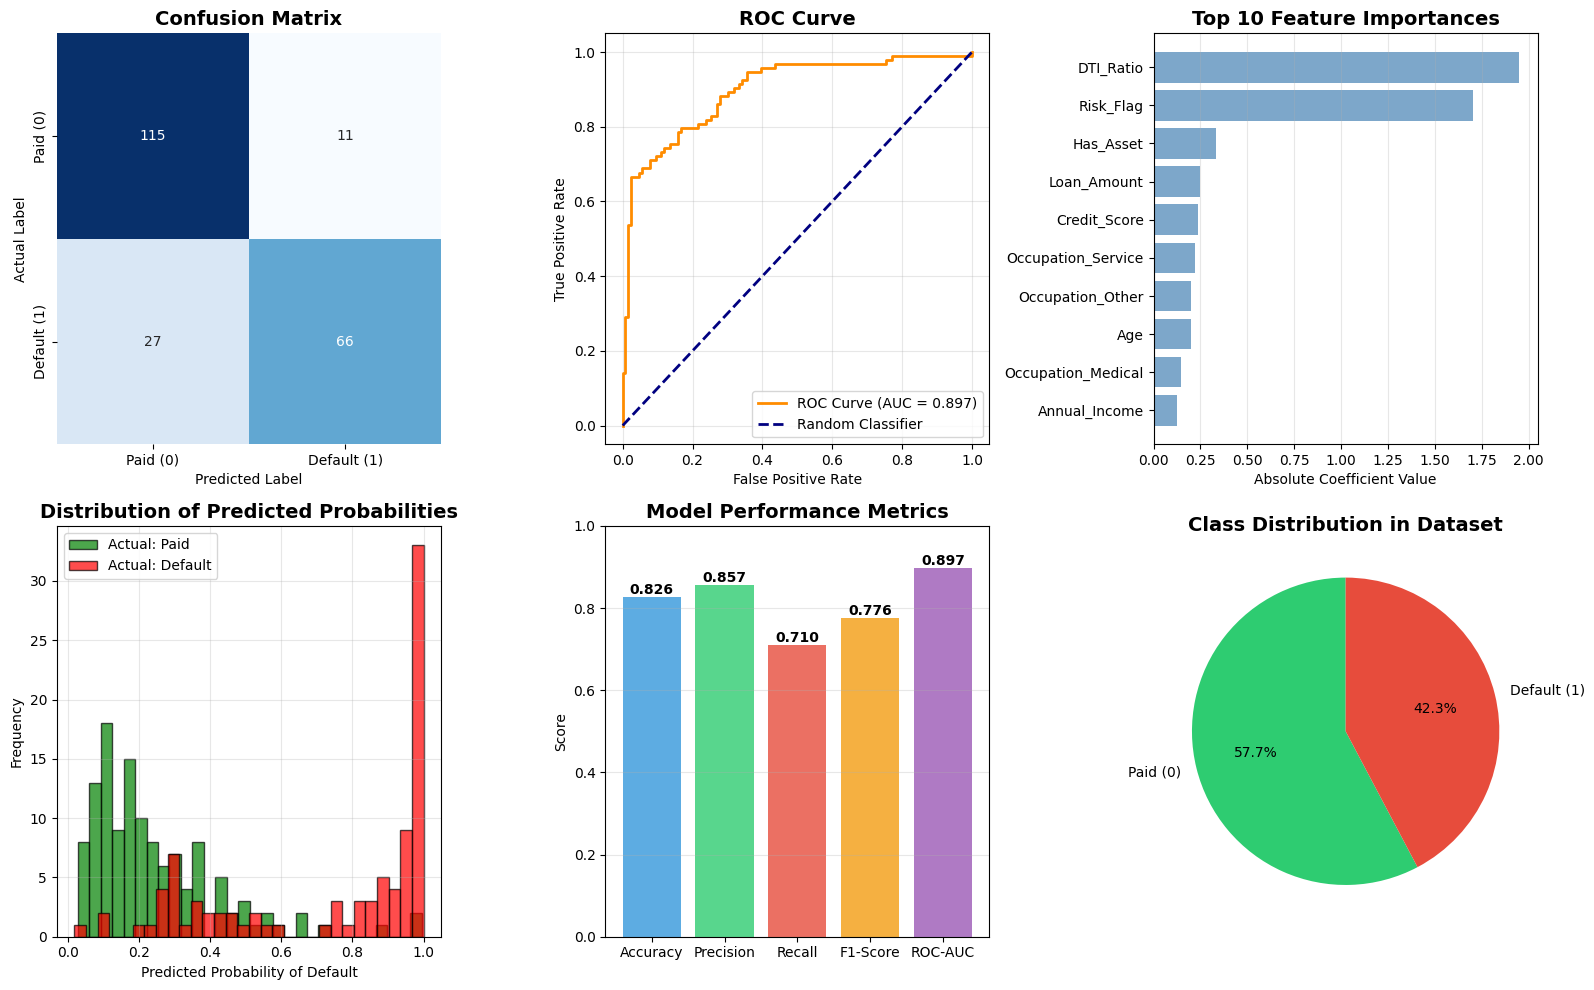

✅ Visualizations Generated.


In [15]:
print("\n" + "="*50)
print("GENERATING VISUALIZATIONS")
print("="*50)

# Calculate metric_precision for the test set, as it was missing from previous calculations
# This ensures all metrics for the bar chart are defined.
metric_precision = precision_score(y_test, y_pred)

# Create a comprehensive visualization
fig = plt.figure(figsize=(16, 10))

# 5.1 Confusion Matrix
ax1 = plt.subplot(2, 3, 1)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax1)
ax1.set_title('Confusion Matrix', fontsize=14, fontweight='bold')
ax1.set_xlabel('Predicted Label')
ax1.set_ylabel('Actual Label')
ax1.set_xticklabels(['Paid (0)', 'Default (1)'])
ax1.set_yticklabels(['Paid (0)', 'Default (1)'])

# 5.2 ROC Curve
ax2 = plt.subplot(2, 3, 2)
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
ax2.plot(fpr, tpr, color='darkorange', lw=2,
         label=f'ROC Curve (AUC = {metric_auc:.3f})')
ax2.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
ax2.set_xlabel('False Positive Rate')
ax2.set_ylabel('True Positive Rate')
ax2.set_title('ROC Curve', fontsize=14, fontweight='bold')
ax2.legend(loc="lower right")
ax2.grid(True, alpha=0.3)

# 5.3 Feature Importance (Top 10)
ax3 = plt.subplot(2, 3, 3)
# Corrected: Use feature_importance_series and get nlargest(10)
top_10_features_plot = feature_importance_series.nlargest(10)
# Since feature_importance_series contains absolute values, using a single color is appropriate.
ax3.barh(top_10_features_plot.index, top_10_features_plot.values, color='steelblue', alpha=0.7)
ax3.set_xlabel('Absolute Coefficient Value')
ax3.set_title('Top 10 Feature Importances', fontsize=14, fontweight='bold')
ax3.grid(True, alpha=0.3, axis='x')
ax3.invert_yaxis() # Display largest at the top

# 5.4 Prediction Distribution
ax4 = plt.subplot(2, 3, 4)
ax4.hist(y_prob[y_test == 0], bins=30, alpha=0.7, label='Actual: Paid', color='green', edgecolor='black')
ax4.hist(y_prob[y_test == 1], bins=30, alpha=0.7, label='Actual: Default', color='red', edgecolor='black')
ax4.set_xlabel('Predicted Probability of Default')
ax4.set_ylabel('Frequency')
ax4.set_title('Distribution of Predicted Probabilities', fontsize=14, fontweight='bold')
ax4.legend()
ax4.grid(True, alpha=0.3)

# 5.5 Performance Metrics Bar Chart
ax5 = plt.subplot(2, 3, 5)
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
metrics_values = [metric_accuracy, metric_precision, metric_recall, metric_f1, metric_auc]
bars = ax5.bar(metrics_names, metrics_values, color=['#3498db', '#2ecc71', '#e74c3c', '#f39c12', '#9b59b6'], alpha=0.8)
ax5.set_ylabel('Score')
ax5.set_title('Model Performance Metrics', fontsize=14, fontweight='bold')
ax5.set_ylim(0, 1)
ax5.grid(True, alpha=0.3, axis='y')
# Add value labels on bars
for bar, value in zip(bars, metrics_values):
    height = bar.get_height()
    ax5.text(bar.get_x() + bar.get_width()/2., height,
             f'{value:.3f}',
             ha='center', va='bottom', fontweight='bold')

# 5.6 Class Distribution
ax6 = plt.subplot(2, 3, 6)
class_counts = y.value_counts()
ax6.pie(class_counts.values, labels=['Paid (0)', 'Default (1)'],
        autopct='%1.1f%%', startangle=90, colors=['#2ecc71', '#e74c3c'])
ax6.set_title('Class Distribution in Dataset', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print("✅ Visualizations Generated.")

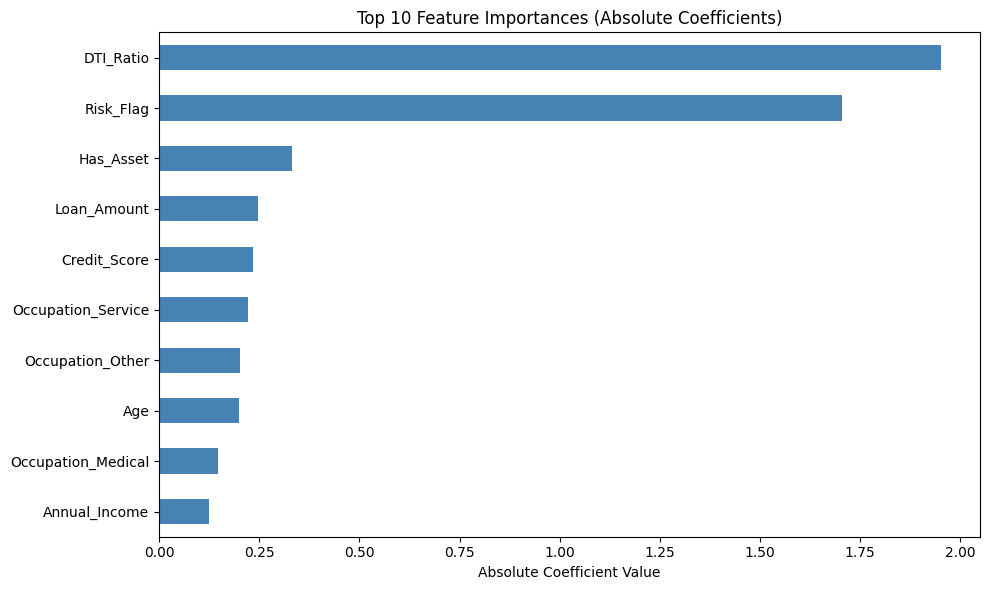

In [16]:
# ==========================================
# STEP 6: Feature Importance Visualization
# ==========================================

plt.figure(figsize=(10, 6))
top_10_features = feature_importance_series.sort_values().tail(10)
top_10_features.plot(kind='barh', color='steelblue')
plt.title('Top 10 Feature Importances (Absolute Coefficients)')
plt.xlabel('Absolute Coefficient Value')
plt.tight_layout()
plt.show()

# INTERPRETATION

In [17]:
# ==========================================
# STEP 7: Display Coefficient Interpretation
# ==========================================

print("\n" + "="*40)
print("COEFFICIENT INTERPRETATION")
print("="*40)
print("Positive coefficients → Increase default probability")
print("Negative coefficients → Decrease default probability")
print("\nTop 5 Positive Predictors of Default:")
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
}).sort_values('Coefficient', ascending=False)
print(coef_df.head())
print("\nTop 5 Negative Predictors of Default:")
print(coef_df.tail())


COEFFICIENT INTERPRETATION
Positive coefficients → Increase default probability
Negative coefficients → Decrease default probability

Top 5 Positive Predictors of Default:
               Feature  Coefficient
7            DTI_Ratio     1.951612
6            Risk_Flag     1.705394
2         Credit_Score     0.235483
0                  Age     0.200396
10  Occupation_Medical     0.146631

Top 5 Negative Predictors of Default:
               Feature  Coefficient
17    Occupation_Trade    -0.083994
11    Occupation_Other    -0.201903
14  Occupation_Service    -0.222424
3          Loan_Amount    -0.247055
5            Has_Asset    -0.332691


# HYPERTUNE

In [41]:
import time
from sklearn.metrics import make_scorer, recall_score
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

print("\n" + "="*60)
print("🔧 STARTING HYPERPARAMETER TUNING WITH GRIDSEARCHCV")
print("="*60)

# Define parameter grid to search
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],  # Regularization strength
    'penalty': ['l1', 'l2', 'elasticnet'],  # Regularization type
    'solver': ['saga'],  # Solver that supports all penalties
    'class_weight': ['balanced', None],  # Handle imbalanced data
    'max_iter': [1000, 2000],  # Maximum iterations
    'l1_ratio': [0.5]  # For elasticnet (only used if penalty='elasticnet')
}

# Create base model
base_model = LogisticRegression(random_state=42)

# Define custom scorer (prioritize recall for catching defaults)
recall_scorer = make_scorer(recall_score)

# Initialize GridSearchCV
# cv=5 means 5-fold cross-validation
# n_jobs=-1 uses all CPU cores
print("\n⏳ This may take a few minutes...")
start_time = time.time()

grid_search = GridSearchCV(
    estimator=base_model,
    param_grid=param_grid,
    cv=5,  # 5-fold cross-validation
    scoring='roc_auc',  # Optimize for ROC-AUC
    n_jobs=-1,  # Use all available cores
    verbose=1,  # Show progress
    return_train_score=True
)

# Fit GridSearchCV
grid_search.fit(X_train_cleaned, y_train_cleaned)

end_time = time.time()
training_time = end_time - start_time


🔧 STARTING HYPERPARAMETER TUNING WITH GRIDSEARCHCV

⏳ This may take a few minutes...
Fitting 5 folds for each of 72 candidates, totalling 360 fits


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(


In [45]:
print(f"Training time: {training_time:.2f} seconds")
print(f"\nBest Parameters Found:")
for param, value in grid_search.best_params_.items():
    print(f"   • {param}: {value}")

print(f"\nBest Cross-Validation ROC-AUC Score: {grid_search.best_score_:.4f}")

# Get top 5 parameter combinations
results_df = pd.DataFrame(grid_search.cv_results_)
top_5_results = results_df.nsmallest(5, 'rank_test_score')[
    ['params', 'mean_test_score', 'std_test_score', 'rank_test_score']
]

print("\nTop 5 Parameter Combinations:")
for idx, row in top_5_results.iterrows():
    print(f"\nRank {int(row['rank_test_score'])}:")
    print(f"   Score: {row['mean_test_score']:.4f} (±{row['std_test_score']:.4f})")
    print(f"   Params: {row['params']}")

# Get the best model
best_model = grid_search.best_estimator_

Training time: 14.70 seconds

Best Parameters Found:
   • C: 0.1
   • class_weight: None
   • l1_ratio: 0.5
   • max_iter: 1000
   • penalty: l1
   • solver: saga

Best Cross-Validation ROC-AUC Score: 0.8967

Top 5 Parameter Combinations:

Rank 1:
   Score: 0.8967 (±0.0221)
   Params: {'C': 0.1, 'class_weight': None, 'l1_ratio': 0.5, 'max_iter': 1000, 'penalty': 'l1', 'solver': 'saga'}

Rank 1:
   Score: 0.8967 (±0.0221)
   Params: {'C': 0.1, 'class_weight': None, 'l1_ratio': 0.5, 'max_iter': 2000, 'penalty': 'l1', 'solver': 'saga'}

Rank 3:
   Score: 0.8966 (±0.0215)
   Params: {'C': 0.1, 'class_weight': 'balanced', 'l1_ratio': 0.5, 'max_iter': 1000, 'penalty': 'l1', 'solver': 'saga'}

Rank 3:
   Score: 0.8966 (±0.0215)
   Params: {'C': 0.1, 'class_weight': 'balanced', 'l1_ratio': 0.5, 'max_iter': 2000, 'penalty': 'l1', 'solver': 'saga'}

Rank 5:
   Score: 0.8956 (±0.0204)
   Params: {'C': 0.1, 'class_weight': 'balanced', 'l1_ratio': 0.5, 'max_iter': 1000, 'penalty': 'elasticnet', 'so

In [47]:
# Evaluate Best Model

print("EVALUATING BEST MODEL ON TEST SET")

# Make predictions
y_pred = best_model.predict(X_test_scaled)
y_prob = best_model.predict_proba(X_test_scaled)[:, 1]

# Calculate metrics
metric_accuracy = accuracy_score(y_test, y_pred)
metric_recall = recall_score(y_test, y_pred)
metric_f1 = f1_score(y_test, y_pred)
metric_auc = roc_auc_score(y_test, y_prob)

print(f"\nTest Set Performance:")
print(f"   Accuracy:  {metric_accuracy:.4f}")
print(f"   Recall:    {metric_recall:.4f} (Crucial for catching defaulters)")
print(f"   F1-Score:  {metric_f1:.4f}")
print(f"   ROC-AUC:   {metric_auc:.4f}")

# Get feature importance
all_coefficients = best_model.coef_[0]
# Corrected: Use feature names from the original DataFrame X
feature_names = X.columns

feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': all_coefficients,
    'Abs_Coefficient': np.abs(all_coefficients)
}).sort_values('Abs_Coefficient', ascending=False)

print("\nTop 10 Most Important Features:")
print(feature_importance_df.head(10)[['Feature', 'Coefficient']].to_string())

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=['Paid', 'Default']))

EVALUATING BEST MODEL ON TEST SET

Test Set Performance:
   Accuracy:  0.8402
   Recall:    0.6774 (Crucial for catching defaulters)
   F1-Score:  0.7826
   ROC-AUC:   0.8956

Top 10 Most Important Features:
               Feature  Coefficient
6            Risk_Flag     1.495552
7            DTI_Ratio     1.461565
5            Has_Asset    -0.203618
0                  Age     0.162368
10  Occupation_Medical     0.107900
2         Credit_Score     0.094383
14  Occupation_Service    -0.075065
11    Occupation_Other    -0.054139
4     Loan_Term_Months     0.053382
13  Occupation_Retired     0.047103

Classification Report:

              precision    recall  f1-score   support

        Paid       0.80      0.96      0.87       126
     Default       0.93      0.68      0.78        93

    accuracy                           0.84       219
   macro avg       0.86      0.82      0.83       219
weighted avg       0.85      0.84      0.83       219



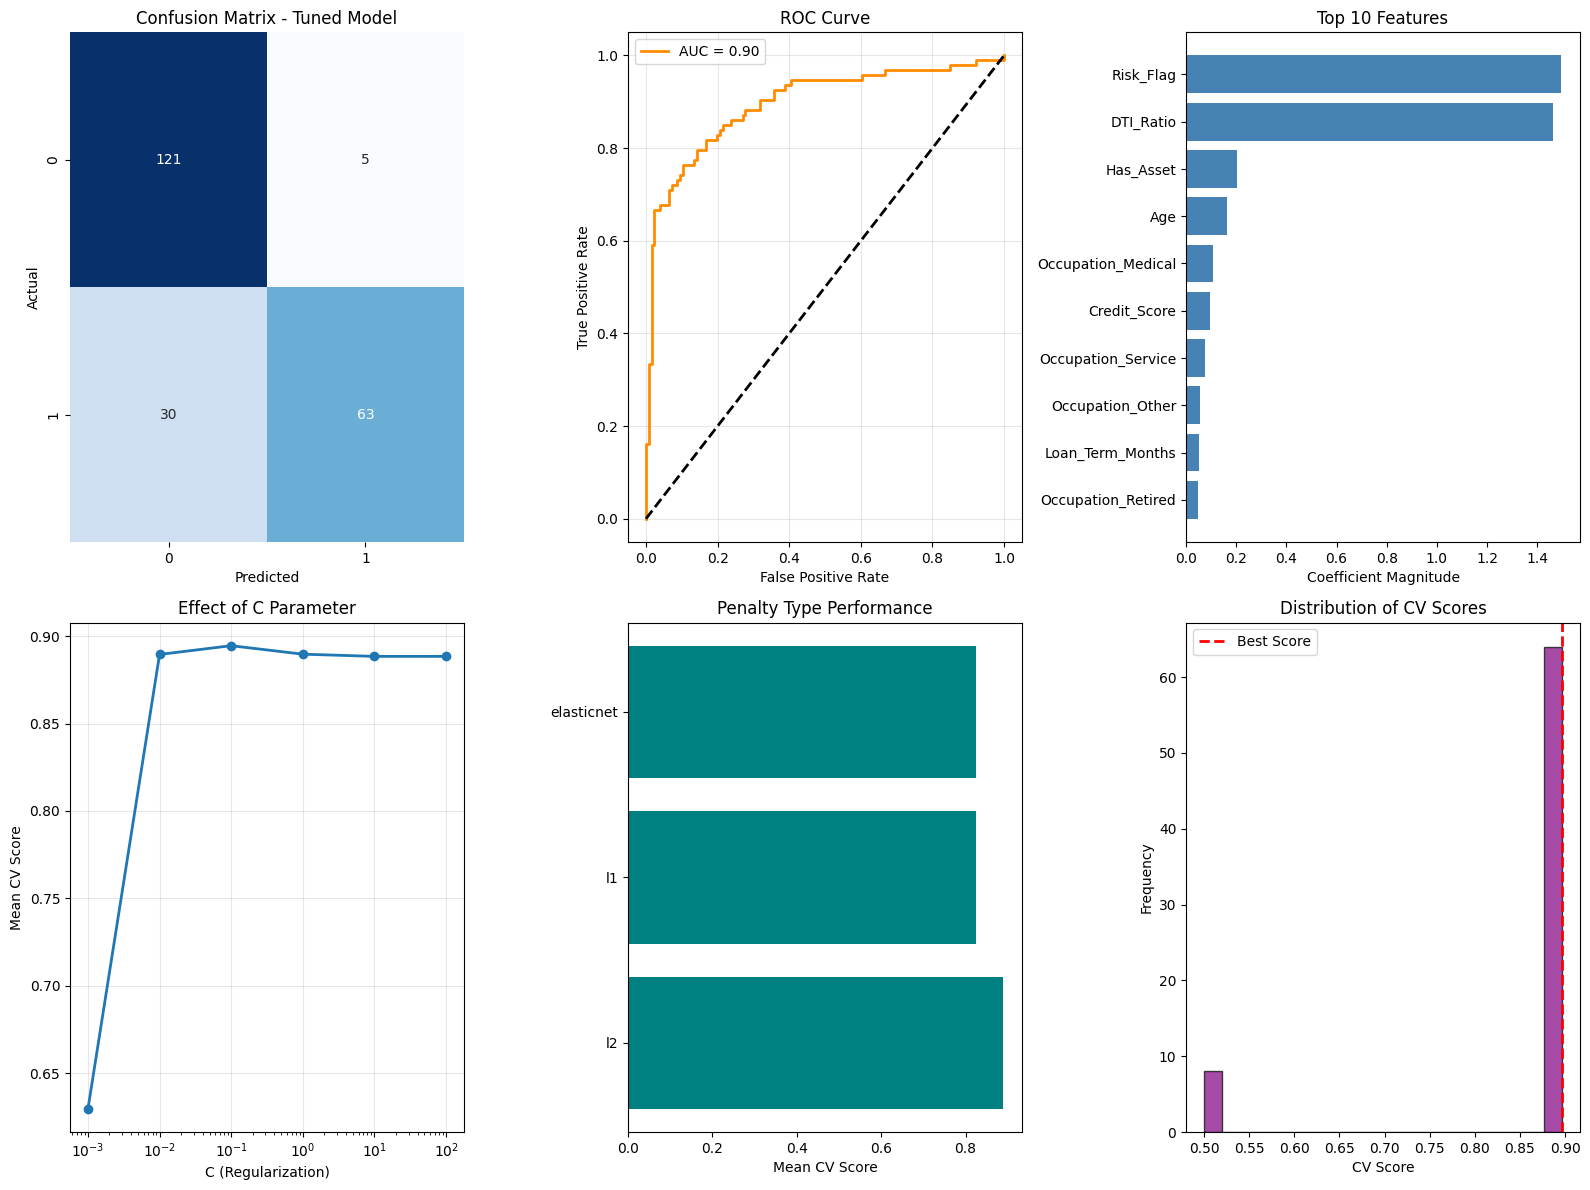

In [48]:
fig = plt.figure(figsize=(16, 12))

# 8.1 Confusion Matrix
plt.subplot(2, 3, 1)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix - Tuned Model')
plt.xlabel('Predicted')
plt.ylabel('Actual')

# 8.2 ROC Curve
plt.subplot(2, 3, 2)
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {metric_auc:.2f}')
plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(alpha=0.3)

# 8.3 Feature Importance
plt.subplot(2, 3, 3)
top_10 = feature_importance_df.head(10)
colors = ['steelblue' if not f.startswith('text_') else 'coral' for f in top_10['Feature']]
plt.barh(range(len(top_10)), top_10['Abs_Coefficient'], color=colors)
plt.yticks(range(len(top_10)), top_10['Feature'])
plt.xlabel('Coefficient Magnitude')
plt.title('Top 10 Features')
plt.gca().invert_yaxis()

# 8.4 Hyperparameter Comparison - C parameter
plt.subplot(2, 3, 4)
c_results = results_df.groupby('param_C')['mean_test_score'].mean()
plt.plot(c_results.index, c_results.values, marker='o', linewidth=2)
plt.xscale('log')
plt.xlabel('C (Regularization)')
plt.ylabel('Mean CV Score')
plt.title('Effect of C Parameter')
plt.grid(alpha=0.3)

# 8.5 Penalty Type Comparison
plt.subplot(2, 3, 5)
penalty_results = results_df.groupby('param_penalty')['mean_test_score'].mean().sort_values()
plt.barh(range(len(penalty_results)), penalty_results.values, color='teal')
plt.yticks(range(len(penalty_results)), penalty_results.index)
plt.xlabel('Mean CV Score')
plt.title('Penalty Type Performance')
plt.gca().invert_yaxis()

# 8.6 Cross-validation Score Distribution
plt.subplot(2, 3, 6)
plt.hist(results_df['mean_test_score'], bins=20, color='purple', alpha=0.7, edgecolor='black')
plt.axvline(grid_search.best_score_, color='red', linestyle='--', linewidth=2, label='Best Score')
plt.xlabel('CV Score')
plt.ylabel('Frequency')
plt.title('Distribution of CV Scores')
plt.legend()

plt.tight_layout()
plt.show()


In [49]:
from sklearn.model_selection import cross_val_score

print("HYPERPARAMETER TUNING SUMMARY")

print(f"\n Total parameter combinations tested: {len(results_df)}")
print(f"Best CV score improvement: {grid_search.best_score_:.4f}")
print(f"  Optimal regularization (C): {grid_search.best_params_['C']}")
print(f"  Optimal penalty: {grid_search.best_params_['penalty']}")
print(f"  Optimal class_weight: {grid_search.best_params_['class_weight']}")

# Cross-validation scores for best model
cv_scores = cross_val_score(best_model, X_train_cleaned, y_train_cleaned, cv=5, scoring='roc_auc')
print(f"\n🎯 Cross-validation scores for best model:")
print(f"   Mean: {cv_scores.mean():.4f}")
print(f"   Std:  {cv_scores.std():.4f}")
print(f"   Individual fold scores: {[f'{score:.4f}' for score in cv_scores]}")

print("\n Hyperparameter tuning complete!")

HYPERPARAMETER TUNING SUMMARY

 Total parameter combinations tested: 72
Best CV score improvement: 0.8967
  Optimal regularization (C): 0.1
  Optimal penalty: l1
  Optimal class_weight: None

🎯 Cross-validation scores for best model:
   Mean: 0.8967
   Std:  0.0221
   Individual fold scores: ['0.8829', '0.9205', '0.9113', '0.8602', '0.9085']

 Hyperparameter tuning complete!


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(


# LLM INSIGHT

In [51]:
import google.generativeai as genai

# ==============================
# 1. CONFIGURE GEMINI
# ==============================
# Replace with your actual API key
from google.colab import userdata

api_key = userdata.get('GEMINI_API_KEY')
genai.configure(api_key=api_key)

# Note: As of early 2026, gemini-2.5-flash is a valid model name.
model_name = "gemini-2.5-flash"

In [52]:
metrics = {
    "accuracy": metric_accuracy,
    "recall": metric_recall,
    "f1": metric_f1,
    "roc_auc": metric_auc
}

In [61]:
prompt = f"""
You are a senior data science consultant.
I trained a Logistic Regression on a financial dataset to predict loan defaults.
Here are the performance metrics:

- Accuracy: {metrics['accuracy']:.2%}
- Recall: {metrics['recall']:.2%}
- F1-score: {metrics['f1']:.2%}
- ROC-AUC: {metrics['roc_auc']:.2%}

Please provide:
1. Summary of model performance
2. Key strengths and weaknesses
3. Suggestions for improvement (hyperparameters, architecture, data)
4. Interpretation of feature importance for Logistic Regression
5. Any potential risks or biases (financial context)
Format your response in a clear, structured, and summarised style.
"""

In [62]:
# In the google-generativeai library, we use GenerativeModel
model = genai.GenerativeModel(
    model_name=model_name,
    generation_config={
        "temperature": 0.2,
        "max_output_tokens": 10000,
    }
)

In [63]:
# ==============================
# 3. GENERATION SETTINGS
# ==============================
# Increase max_output_tokens to allow for a full report
generation_config = {
    "max_output_tokens": 20408,  # Increased from default
    "temperature": 0.7,
}

# Use the config in the generate_content call
response = model.generate_content(prompt, generation_config=generation_config)

# ==============================
# 4. OUTPUT
# ==============================
if response.text:
    print(response.text)
else:
    # If it's empty, it might be a safety filter block
    print("No response. Check response.prompt_feedback or safety settings.")

Here's a structured summary and analysis of your Logistic Regression model for loan default prediction:

---

### Logistic Regression Model Performance Review: Loan Default Prediction

**1. Summary of Model Performance**

Your Logistic Regression model demonstrates a strong overall ability to distinguish between defaulting and non-defaulting loans, as indicated by its high ROC-AUC. It achieves a good general accuracy and a reasonable balance between precision and recall (F1-score). However, there is a notable area for improvement in identifying a significant portion of actual defaulting loans.

**2. Key Strengths and Weaknesses**

*   **Key Strengths:**
    *   **ROC-AUC (89.56%): Excellent Discriminative Power.** This is the standout metric. It indicates that the model is very good at ranking borrowers by their likelihood of default, meaning it can effectively separate high-risk from low-risk applicants across various decision thresholds. This is crucial for risk management.
    *   *

In [64]:
print("Best Hyperparameters for Logistic Regression:")
for param, value in grid_search.best_params_.items():
    print(f"  {param}: {value}")

Best Hyperparameters for Logistic Regression:
  C: 0.1
  class_weight: None
  l1_ratio: 0.5
  max_iter: 1000
  penalty: l1
  solver: saga


<a href="https://colab.research.google.com/github/hanidew/WIE3007-DMW-GroupProject/blob/feature%2Fhani-naive-bayes-model/DMW_GA_(Hani)_Naive_Bayes_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Part A: Naive Bayes Model & Metrics

## STEP 1: SETUP & DATA PREPROCESSING
- handles all the data preparation.
- It cleans the columns, converts categories to numbers, and scales the data

In [ ]:
# ==========================================
# STEP 1: Imports & Data Preprocessing
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, f1_score, recall_score
)

# 1. Load Data
# We use the dataset where we already fixed the text features
df = pd.read_csv('synthetic_data_cleaned_feature_engineered.csv', sep='|')

# 2. Define Features (X) and Target (y)
# We drop 'Loan_Officer_Note' because we already extracted 'Risk_Flag' from it.
# We drop 'Customer_ID' because it is just a random label.
X = df.drop(columns=['Customer_ID', 'Loan_Officer_Note', 'Default_Status'])
y = df['Default_Status']

# 3. Handle Categorical Data ('Occupation')
# Naive Bayes handles numbers, not words. We use "One-Hot Encoding"
# to turn 'Occupation' into columns like 'Occupation_Teacher', 'Occupation_Tech', etc.
X = pd.get_dummies(X, columns=['Occupation'], drop_first=True)

# 4. Scale the Data (CRITICAL for Naive Bayes)
# Gaussian Naive Bayes assumes data follows a normal "bell curve".
# Scaling ensures features like Income ($50,000) and Age (30) don't confuse the model due to size differences.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

# 5. Split Data (80% Train, 20% Test)
# stratify=y ensures we have the same percentage of defaulters in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f"✅ Data Processed. Training on {len(X_train)} rows, Testing on {len(X_test)} rows.")

✅ Data Processed. Training on 872 rows, Testing on 219 rows.


## STEP 2: MODEL TRAINING
- Initializes the Gaussian Naive Bayes algorithm
- Teaches model using the training data

In [ ]:
# ==========================================
# STEP 2: Train Naive Bayes Model
# ==========================================
print("🤖 Training Gaussian Naive Bayes...")

# Initialize the model
nb_model = GaussianNB()

# Fit the model (The learning phase)
nb_model.fit(X_train, y_train)

# Generate predictions on the test set
y_pred = nb_model.predict(X_test)
y_prob = nb_model.predict_proba(X_test)[:, 1]  # Get probabilities for ROC-AUC calculation

print("✅ Model Trained successfully!")

🤖 Training Gaussian Naive Bayes...
✅ Model Trained successfully!


## STEP 3: EVALUATION METRICS

In [ ]:
# ==========================================
# STEP 3: Evaluate Performance
# ==========================================
# Calculate core metrics
metric_accuracy = accuracy_score(y_test, y_pred)
metric_recall = recall_score(y_test, y_pred) # Crucial: Did we catch the bad guys?
metric_f1 = f1_score(y_test, y_pred)         # Balance between Precision and Recall
metric_auc = roc_auc_score(y_test, y_prob)   # Overall distinguishing power

print("\n--- MODEL METRICS ---")
print(f"Accuracy:  {metric_accuracy:.2%}")
print(f"Recall:    {metric_recall:.2%} (The ability to find actual defaulters)")
print(f"F1 Score:  {metric_f1:.4f}")
print(f"ROC-AUC:   {metric_auc:.4f}")

print("\n--- DETAILED REPORT ---")
print(classification_report(y_test, y_pred))


--- MODEL METRICS ---
Accuracy:  80.82%
Recall:    68.82% (The ability to find actual defaulters)
F1 Score:  0.7529
ROC-AUC:   0.8649

--- DETAILED REPORT ---
              precision    recall  f1-score   support

           0       0.80      0.90      0.84       126
           1       0.83      0.69      0.75        93

    accuracy                           0.81       219
   macro avg       0.81      0.79      0.80       219
weighted avg       0.81      0.81      0.80       219



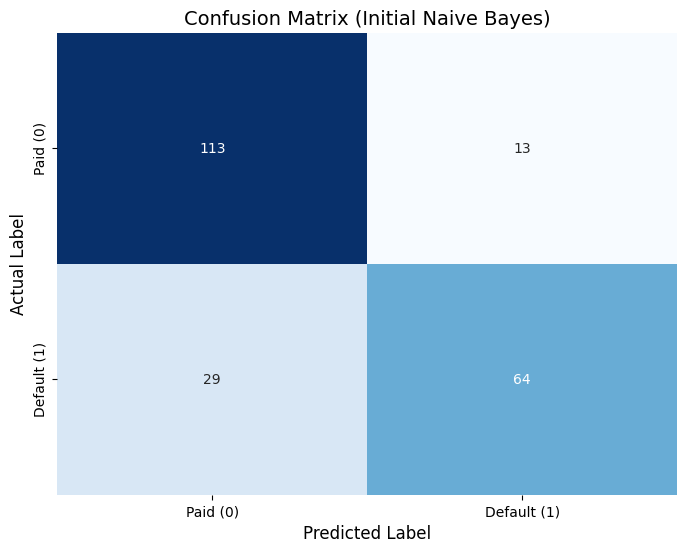


--- INITIAL MATRIX INTERPRETATION ---
✅ True Negatives (Correctly predicted 'Paid'): 113
❌ False Positives (Predicted 'Default' but paid): 13
⚠️ False Negatives (Predicted 'Paid' but defaulted): 29 (This is the critical error)
✅ True Positives (Correctly predicted 'Default'): 64


In [ ]:
# ==========================================
# STEP 3.5: Confusion Matrix (Before Tuning)
# ==========================================
# 1. Compute Matrix
cm_initial = confusion_matrix(y_test, y_pred)

# 2. Plot
plt.figure(figsize=(8, 6))
sns.heatmap(cm_initial, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Paid (0)', 'Default (1)'],
            yticklabels=['Paid (0)', 'Default (1)'])

plt.title('Confusion Matrix (Initial Naive Bayes)', fontsize=14)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('Actual Label', fontsize=12)
plt.show()

# 3. Interpretation
tn, fp, fn, tp = cm_initial.ravel()
print("\n--- INITIAL MATRIX INTERPRETATION ---")
print(f"✅ True Negatives (Correctly predicted 'Paid'): {tn}")
print(f"❌ False Positives (Predicted 'Default' but paid): {fp}")
print(f"⚠️ False Negatives (Predicted 'Paid' but defaulted): {fn} (This is the critical error)")
print(f"✅ True Positives (Correctly predicted 'Default'): {tp}")

## STEP 4: FEATURE IMPORTANCE & VISUALIZATIONS
- Use a technique called "Permutation Importance" (shuffling data to see what breaks the model) to find out which features matter most

🔍 Calculating Feature Importance (Permutation Method)...

--- TOP 5 PREDICTIVE FEATURES ---
- Risk_Flag: 0.1607
- DTI_Ratio: 0.1009
- Loan_Term_Months: 0.0183
- Loan_Amount: 0.0169
- Has_Asset: 0.0110



/tmp/ipython-input-2763479080.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=top_5, palette='viridis')


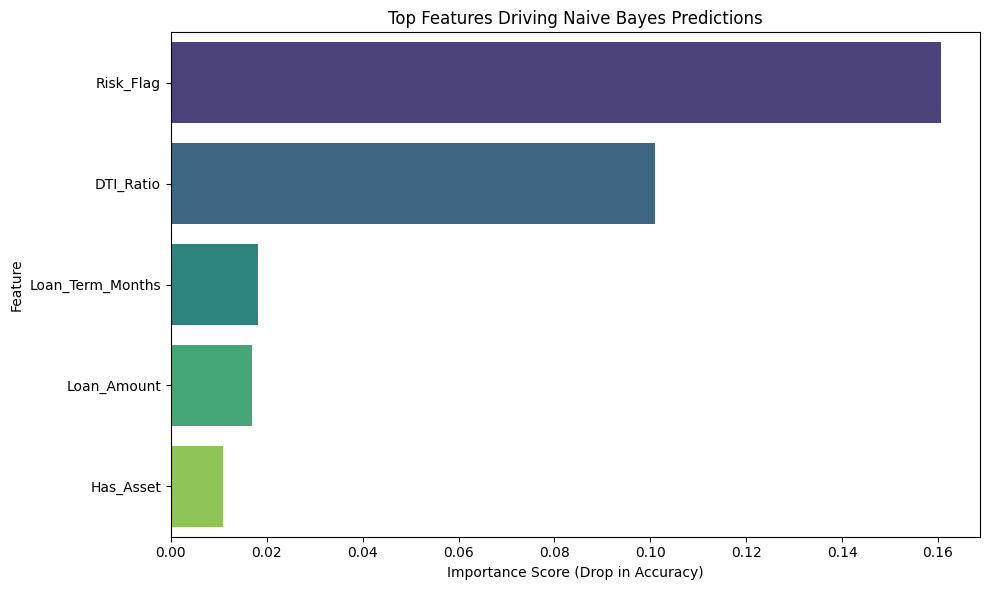

In [ ]:
# ==========================================
# STEP 4: Visualizing Feature Importance
# ==========================================
print("🔍 Calculating Feature Importance (Permutation Method)...")

# We shuffle each feature one by one to see how much the accuracy drops.
# If accuracy drops a lot, that feature was very important.
perms = permutation_importance(nb_model, X_test, y_test, n_repeats=10, random_state=42)

# Create a DataFrame to organize results
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': perms.importances_mean
}).sort_values(by='Importance', ascending=False)

# Format top 5 features for the LLM prompt later
top_5 = feature_importance.head(5)
top_features_str = ""
for index, row in top_5.iterrows():
    top_features_str += f"- {row['Feature']}: {row['Importance']:.4f}\n"

print("\n--- TOP 5 PREDICTIVE FEATURES ---")
print(top_features_str)

# Plot the graph
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=top_5, palette='viridis')
plt.title('Top Features Driving Naive Bayes Predictions')
plt.xlabel('Importance Score (Drop in Accuracy)')
plt.tight_layout()
plt.show()

## 4.5 Hyperparameter Tuning
While Naive Bayes is a simple algorithm with very few "knobs" to turn, there is one key hyperparameter you can tune: var_smoothing.

What it does: It adds a tiny amount of noise to the data's variance. This helps stability and can sometimes help the model handle "weird" data points or skewed distributions better

In [ ]:
# ==========================================
# STEP 4.5: Hyperparameter Tuning (Grid Search)
# ==========================================
from sklearn.model_selection import GridSearchCV

print("🔧 Starting Hyperparameter Tuning for Naive Bayes...")

# 1. Define the Parameter Grid
# 'var_smoothing' is the main knob for Naive Bayes (handles data variances)
param_grid = {
    'var_smoothing': np.logspace(0, -9, num=100)
}

# 2. Setup Grid Search
grid_search = GridSearchCV(
    estimator=GaussianNB(),
    param_grid=param_grid,
    cv=5,
    scoring='recall',  # Optimizing for Recall (catching defaulters)
    verbose=1,
    n_jobs=-1
)

# 3. Fit the Search
grid_search.fit(X_train, y_train)
best_nb_model = grid_search.best_estimator_

print(f"\n✅ Tuning Complete! Best var_smoothing: {grid_search.best_params_['var_smoothing']:.9f}")

# 4. Evaluate Tuned Model
y_pred_tuned = best_nb_model.predict(X_test)
y_prob_tuned = best_nb_model.predict_proba(X_test)[:, 1] # Needed for ROC-AUC

# Calculate New Metrics
tuned_acc = accuracy_score(y_test, y_pred_tuned)
tuned_recall = recall_score(y_test, y_pred_tuned)
tuned_f1 = f1_score(y_test, y_pred_tuned)
tuned_auc = roc_auc_score(y_test, y_prob_tuned)

# 5. Print formatted results
print("\n--- MODEL METRICS ---")
print(f"Accuracy:  {tuned_acc:.2%}")
print(f"Recall:    {tuned_recall:.2%} (The ability to find actual defaulters)")
print(f"F1 Score:  {tuned_f1:.4f}")
print(f"ROC-AUC:   {tuned_auc:.4f}")

print("\n--- DETAILED REPORT ---")
print(classification_report(y_test, y_pred_tuned))

# 6. Comparison Table (Before vs After)
print("\n" + "="*55)
print("📊 TUNING IMPACT ANALYSIS (Before vs After)")
print("="*55)
print(f"{'Metric':<15} | {'Before':<10} | {'After':<10} | {'Change':<10}")
print("-" * 55)
print(f"{'Accuracy':<15} | {metric_accuracy:.2%}     | {tuned_acc:.2%}     | {tuned_acc - metric_accuracy:+.2%}")
print(f"{'Recall':<15} | {metric_recall:.2%}     | {tuned_recall:.2%}     | {tuned_recall - metric_recall:+.2%}")
print(f"{'F1 Score':<15} | {metric_f1:.4f}     | {tuned_f1:.4f}     | {tuned_f1 - metric_f1:+.4f}")
print(f"{'ROC-AUC':<15} | {metric_auc:.4f}     | {tuned_auc:.4f}     | {tuned_auc - metric_auc:+.4f}")
print("="*55)

# Update variables for the LLM step (Optional - if you want LLM to analyze the NEW model)
# metric_accuracy = tuned_acc
# metric_recall = tuned_recall
# metric_f1 = tuned_f1
# metric_auc = tuned_auc

🔧 Starting Hyperparameter Tuning for Naive Bayes...
Fitting 5 folds for each of 100 candidates, totalling 500 fits

✅ Tuning Complete! Best var_smoothing: 0.018738174

--- MODEL METRICS ---
Accuracy:  80.82%
Recall:    68.82% (The ability to find actual defaulters)
F1 Score:  0.7529
ROC-AUC:   0.8601

--- DETAILED REPORT ---
              precision    recall  f1-score   support

           0       0.80      0.90      0.84       126
           1       0.83      0.69      0.75        93

    accuracy                           0.81       219
   macro avg       0.81      0.79      0.80       219
weighted avg       0.81      0.81      0.80       219


📊 TUNING IMPACT ANALYSIS (Before vs After)
Metric          | Before     | After      | Change    
-------------------------------------------------------
Accuracy        | 80.82%     | 80.82%     | +0.00%
Recall          | 68.82%     | 68.82%     | +0.00%
F1 Score        | 0.7529     | 0.7529     | +0.0000
ROC-AUC         | 0.8649     | 0.8601

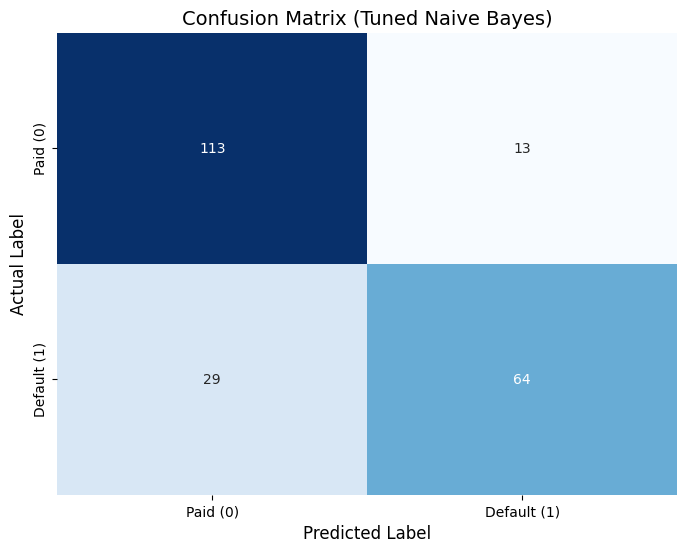


--- MATRIX INTERPRETATION ---
✅ True Negatives (Correctly predicted 'Paid'): 113
❌ False Positives (Predicted 'Default' but paid): 13 (Lost Business)
⚠️ False Negatives (Predicted 'Paid' but defaulted): 29 (Dangerous Risk!)
✅ True Positives (Correctly predicted 'Default'): 64


In [ ]:
# ==========================================
# STEP 4.6: Visualizing the Confusion Matrix
# ==========================================
from sklearn.metrics import ConfusionMatrixDisplay

# 1. Compute Matrix
cm = confusion_matrix(y_test, y_pred_tuned)

# 2. Plot
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Paid (0)', 'Default (1)'],
            yticklabels=['Paid (0)', 'Default (1)'])

plt.title('Confusion Matrix (Tuned Naive Bayes)', fontsize=14)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('Actual Label', fontsize=12)
plt.show()

# 3. Interpretation Printout
tn, fp, fn, tp = cm.ravel()
print("\n--- MATRIX INTERPRETATION ---")
print(f"✅ True Negatives (Correctly predicted 'Paid'): {tn}")
print(f"❌ False Positives (Predicted 'Default' but paid): {fp} (Lost Business)")
print(f"⚠️ False Negatives (Predicted 'Paid' but defaulted): {fn} (Dangerous Risk!)")
print(f"✅ True Positives (Correctly predicted 'Default'): {tp}")

# Part B: The LLM Analysis (The Insight)
Use LLMs to summarise findings, provide insights, and interpret feature importance.

In [ ]:
import google.generativeai as genai

# ==============================
# 1. CONFIGURE GEMINI
# ==============================
# Replace with your actual API key
from google.colab import userdata

api_key = userdata.get('GEMINI_KEY')
genai.configure(api_key=api_key)

# Note: As of early 2026, gemini-2.5-flash is a valid model name.
model_name = "gemini-2.5-flash"

# 2. DEFINE THE PROMPT
# We use the metrics from your Tuned Model (Step 4.5)
prompt = f"""
You are a Senior Data Science Consultant for a bank.
I have trained a Gaussian Naive Bayes model to predict Loan Defaults.

Here are the final performance metrics after hyperparameter tuning:
- Accuracy: {tuned_acc:.2%}
- Recall: {tuned_recall:.2%} (Ability to catch actual defaulters)
- F1-Score: {tuned_f1:.4f}
- ROC-AUC: {tuned_auc:.4f}

Top 5 Predictive Features (Permutation Importance):
{top_features_str}

Please generate a formal "Model Performance Report" with these exact sections:

1. Executive Summary
   - Is this model ready for deployment? (Focus on the Recall score).
   - How does it compare to random guessing (ROC-AUC)?

2. Feature Interpretation
   - Explain WHY the top features are predictive in a banking context.
   - Example: If 'Income' is high, explain why that lowers risk.

3. Strategic Recommendations
   - Naive Bayes assumes features are independent. Explain why this is a weakness for financial data (e.g., Debt is related to Income).
   - Suggest one alternative model (e.g., XGBoost or Random Forest) and why it might work better.

Format: Professional, clear, and ready for a stakeholder presentation.
"""

# In the google-generativeai library, we use GenerativeModel
model = genai.GenerativeModel(
    model_name=model_name,
    generation_config={
        "temperature": 0.2,
        "max_output_tokens": 10000,
    }
)

# ==============================
# 3. GENERATION SETTINGS
# ==============================
# Increase max_output_tokens to allow for a full report
generation_config = {
    "max_output_tokens": 20408,  # Increased from default
    "temperature": 0.7,
}

# Use the config in the generate_content call
response = model.generate_content(prompt, generation_config=generation_config)

# ==============================
# 4. OUTPUT
# ==============================
if response.text:
    print(response.text)
else:
    # If it's empty, it might be a safety filter block
    print("No response. Check response.prompt_feedback or safety settings.")

## Model Performance Report: Loan Default Prediction (Gaussian Naive Bayes)

**Date:** October 26, 2023
**Prepared For:** Senior Management & Risk Committee
**Prepared By:** [Your Name/Department], Senior Data Science Consultant

---

### 1. Executive Summary

This report details the performance of a recently trained Gaussian Naive Bayes model designed to predict loan defaults. The model achieved an Accuracy of 80.82%, a Recall of 68.82%, an F1-Score of 0.7529, and an ROC-AUC of 0.8601.

**Is this model ready for deployment?**
While the overall accuracy is reasonably high at 80.82%, and the ROC-AUC indicates good discriminative power, the **Recall score of 68.82% presents a significant concern for immediate deployment.** Recall is the model's ability to correctly identify actual defaulters. A 68.82% recall means that approximately **one-third (31.18%) of all actual loan defaulters would be missed by this model.** In the context of loan defaults, a False Negative (missing an actual defa

# Git

In [ ]:
# ==========================================
# 🚀 AUTOMATED GITHUB PUSH (Branch Edition)
# ==========================================
import os

# --- 1. CONFIGURATION (Change these!) ---
USER_NAME = "hanidew"
USER_EMAIL = "hanijasmina@gmail.com"
TOKEN = "GIT_TOKEN"  # Paste your Token here
REPO_NAME = "WIE3007-DMW-GroupProject"
FILE_NAME = "DMW_GA (Hani) - Naive Bayes Model.ipynb"
COMMIT_MESSAGE = "Updated git command code"

# 🔴 NEW CHANGE: Define your branch name here
BRANCH_NAME = "feature/hani-naive-bayes-model"

# --- 2. THE MAGIC SCRIPT ---
# Clone the repo silently
repo_url = f"https://{TOKEN}@github.com/{USER_NAME}/{REPO_NAME}.git"

!git config --global user.email "{USER_EMAIL}"
!git config --global user.name "{USER_NAME}"

# Remove existing repo dir if it exists to avoid conflicts
if os.path.exists(REPO_NAME):
    !rm -rf {REPO_NAME}

# Clone
!git clone {repo_url}

# Move into the directory
%cd {REPO_NAME}

# 🔴 NEW CHANGE: Create and switch to the new branch
!git checkout -b {BRANCH_NAME}

# Copy the current notebook into the repo folder
# (We need to copy it AFTER moving into the directory or use full paths.
#  The previous script copied it *before* cd-ing, but to be safe with branches
#  let's use the parent directory path '..' to find the file)
!cp "../{FILE_NAME}" .

# Add, Commit
!git add .
!git commit -m "{COMMIT_MESSAGE}"

# 🔴 NEW CHANGE: Push to the specific branch
!git push origin {BRANCH_NAME}

# Move back
%cd ..
print(f"\n✅ SUCCESS! File pushed to branch '{BRANCH_NAME}' at https://github.com/{USER_NAME}/{REPO_NAME}/tree/{BRANCH_NAME}")

<a href="https://colab.research.google.com/github/hanidew/WIE3007-DMW-GroupProject/blob/MLP/MLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MLP

## Import libraries

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


## Load Dataset

In [ ]:
# Load dataset
file_path = "/content/synthetic_data_cleaned_feature_engineered.csv"
df = pd.read_csv(file_path, sep="|")
#df = pd.read_csv(file_path)
# View first rows
df.head()


,Customer_ID,Age,Annual_Income,Credit_Score,Loan_Amount,Loan_Term_Months,Loan_Officer_Note,Default_Status,Occupation,Has_Asset,Risk_Flag,DTI_Ratio,Log_Income
0,CUST-4321,55,120000,770,160000,48,Teaching assistant facing sudden hospital bill...,1,Education,0,0,1.333322,11.695255
1,CUST-2056,40,150000,780,90000,36,Photographer inherits art collection easing fi...,0,Other,0,0,0.599996,11.918397
2,CUST-9812,34,75000,660,110000,48,Retail store owner deals daily challenges due ...,1,Service,0,0,1.466647,11.225257
3,CUST-8132,28,32000,710,60000,24,Software developer secures bonus which helps c...,0,Tech,1,0,1.874941,10.373522
4,CUST-0543,45,80000,820,240000,72,Business consultant recently benefited from su...,1,Business,0,0,2.999963,11.289794


In [ ]:
df.isnull().sum()


,0
Customer_ID,0
Age,0
Annual_Income,0
Credit_Score,0
Loan_Amount,0
Loan_Term_Months,0
Loan_Officer_Note,0
Default_Status,0
Occupation,0
Has_Asset,0


## Data Preprocessing

### Train-Test Split (80% Train, 20% Test)

In [ ]:
X = df.drop(columns=["Default_Status"])
y = df["Default_Status"]
#X = df.drop(columns=["default_risk"])
#y = df["default_risk"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)


### Identify categorical and numeric columns


In [ ]:
categorical_cols = X.select_dtypes(include=["object"]).columns
numeric_cols = X.select_dtypes(exclude=["object"]).columns

print("Categorical columns:", list(categorical_cols))
print("Numeric columns:", list(numeric_cols))




Categorical columns: ['Customer_ID', 'Loan_Officer_Note', 'Occupation']
Numeric columns: ['Age', 'Annual_Income', 'Credit_Score', 'Loan_Amount', 'Loan_Term_Months', 'Has_Asset', 'Risk_Flag', 'DTI_Ratio', 'Log_Income']


### Preprocessing Pipeline

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.neural_network import MLPClassifier

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_cols)
    ]
)


## Build MLP Pipeline

In [ ]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.neural_network import MLPClassifier

mlp_pipeline = Pipeline(
    steps=[
        ("preprocess", preprocessor),
       # ("smote", SMOTE(random_state=45)),
        ("model", MLPClassifier(
            hidden_layer_sizes=(64, 32),
            max_iter=500,
            random_state=42
        ))
    ]
)


## Train Model

In [ ]:
mlp_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['Age', 'Annual_Income', 'Credit_Score', 'Loan_Amount',
       'Loan_Term_Months', 'Has_Asset', 'Risk_Flag', 'DTI_Ratio',
       'Log_Income'],
      dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  Index(['Customer_ID', 'Loan_Officer_Note', 'Occupation'], dtype='object'))])),
                ('model',
                 MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500,
                               random_state=42))])

## Evaluation

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)
# Predict class labels (0 or 1)
y_pred = mlp_pipeline.predict(X_test)



/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [ ]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred)

print("Model Evaluation (MLP Classifier)")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")
print(f"ROC-AUC:, {auc:.4f}" )



Model Evaluation (MLP Classifier)
Accuracy : 0.7945
Precision: 0.7857
Recall   : 0.7097
F1-score : 0.7458
ROC-AUC:, 0.7834


### Evaluation Report

In [ ]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.86      0.83       126
           1       0.79      0.71      0.75        93

    accuracy                           0.79       219
   macro avg       0.79      0.78      0.79       219
weighted avg       0.79      0.79      0.79       219



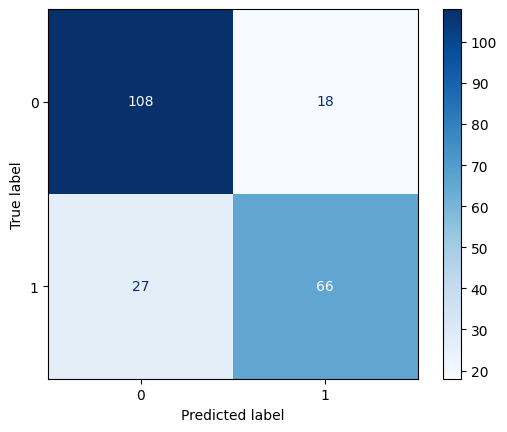

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

disp = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test, y_pred),
    display_labels=[0, 1]
)

disp.plot(cmap="Blues")  # blue gradient
plt.show()


## Hypertune

### Optuna

In [ ]:
!pip install optuna
import optuna
from sklearn.model_selection import cross_val_score


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 404.7/404.7 kB 33.3 MB/s eta 0:00:00


In [ ]:
def objective(trial):

    hidden_layer_sizes = (
        trial.suggest_int("n_units_l1", 32, 128),
        trial.suggest_int("n_units_l2", 16, 64)
    )

    alpha = trial.suggest_float("alpha", 1e-5, 1e-2, log=True)
    learning_rate_init = trial.suggest_float("learning_rate_init", 1e-4, 1e-2, log=True)

    mlp = MLPClassifier(
        hidden_layer_sizes=hidden_layer_sizes,
        activation="relu",
        solver="adam",
        alpha=alpha,
        learning_rate_init=learning_rate_init,
        max_iter=300,
        random_state=42
    )

    pipeline = Pipeline(
        steps=[
            ("preprocess", preprocessor),
            ("model", mlp)
        ]
    )

    score = cross_val_score(
        pipeline,
        X_train,
        y_train,
        cv=3,
        scoring="roc_auc"
    ).mean()

    return score


In [ ]:
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=40)


[I 2026-01-18 17:20:29,238] A new study created in memory with name: no-name-fc2ae238-9745-45ff-a4a1-c7a688969c5c
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
[I 2026-01-18 17:20:37,341] Trial 0 finished with value: 0.8628036880485901 and parameters: {'n_units_l1': 46, 'n_units_l2': 53, 'alpha': 0.005434797558241521, 'learning_rate_init': 0.0010005912161508087}. Best 

In [ ]:
print("Best ROC-AUC:", study.best_value)
print("Best Parameters:", study.best_params)


Best ROC-AUC: 0.8819179999957689
Best Parameters: {'n_units_l1': 104, 'n_units_l2': 30, 'alpha': 3.759187927626414e-05, 'learning_rate_init': 0.00010197334077425832}


#Hypertune Model

In [ ]:
mlp_pipeline = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("model", MLPClassifier(
            hidden_layer_sizes=(104, 30),  # n_units_l1, n_units_l2
            activation="relu",
            solver="adam",
            alpha=3.759187927626414e-05,
            learning_rate_init=0.00010197334077425832,
            max_iter=300,
            random_state=42
        ))
    ]
)


## Run  Model with Hyperparameter

In [ ]:
mlp_pipeline.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['Age', 'Annual_Income', 'Credit_Score', 'Loan_Amount',
       'Loan_Term_Months', 'Has_Asset', 'Risk_Flag', 'DTI_Ratio',
       'Log_Income'],
      dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  Index(['Customer_ID', 'Loan_Officer_Note', 'Occupation'], dtype='object'))])),
                ('model',
                 MLPClassifier(alpha=3.759187927626414e-05,
                               hidden_layer_sizes=(104, 30),
                               learning_rate_init=0.00010197334077425832,
                               max_iter=300, random_state=42))])

## Evaluation

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)
# Predict class labels (0 or 1)
y_pred = mlp_pipeline.predict(X_test)



/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [ ]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred)

print("Model Evaluation (MLP Classifier)")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")
print(f"ROC-AUC:, {auc:.4f}" )



Model Evaluation (MLP Classifier)
Accuracy : 0.8174
Precision: 0.8630
Recall   : 0.6774
F1-score : 0.7590
ROC-AUC:, 0.7990


### Evaluation Report

In [ ]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.92      0.85       126
           1       0.86      0.68      0.76        93

    accuracy                           0.82       219
   macro avg       0.83      0.80      0.81       219
weighted avg       0.82      0.82      0.81       219



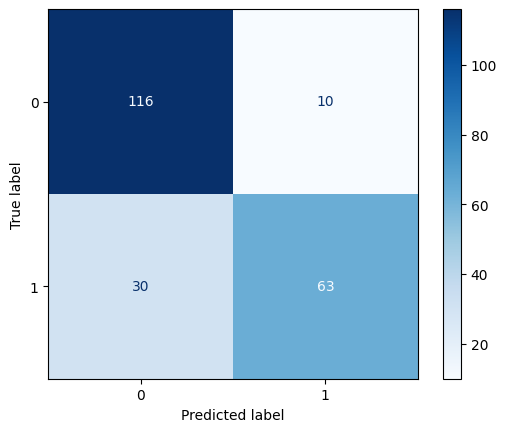

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

disp = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test, y_pred),
    display_labels=[0, 1]
)

disp.plot(cmap="Blues")  # blue gradient
plt.show()


# Part B: The LLM Analysis (The Insight)
Use LLMs to summarise findings, provide insights, and interpret feature importance.

In [ ]:
import google.generativeai as genai

# ==============================
# 1. CONFIGURE GEMINI
# ==============================
# Replace with your actual API key
from google.colab import userdata

api_key = userdata.get('GEMINI_API_KEY')
genai.configure(api_key=api_key)

# Note: As of early 2026, gemini-2.5-flash is a valid model name.
model_name = "gemini-2.5-flash"

/usr/local/lib/python3.12/dist-packages/google/colab/_import_hooks/_hook_injector.py:55: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  loader.exec_module(module)


In [ ]:
metrics = {
    "accuracy": accuracy,
    "precision": precision,
    "recall": recall,
    "f1": f1,
    "roc_auc": auc
}

In [ ]:
prompt = f"""
You are a senior data science consultant.
I trained a Multi-Layer Perceptron (MLP) on a financial dataset to predict loan defaults.
Here are the performance metrics:

- Accuracy: {metrics['accuracy']:.2%}
- Precision: {metrics['precision']:.2%}
- Recall: {metrics['recall']:.2%}
- F1-score: {metrics['f1']:.2%}
- ROC-AUC: {metrics['roc_auc']:.2%}

Please provide:
1. Summary of model performance
2. Key strengths and weaknesses
3. Suggestions for improvement (hyperparameters, architecture, data)
4. Interpretation of feature importance for an MLP
5. Any potential risks or biases (financial context)
Format your response in a clear, structured, professional report style.
"""

In [ ]:
# In the google-generativeai library, we use GenerativeModel
model = genai.GenerativeModel(
    model_name=model_name,
    generation_config={
        "temperature": 0.2,
        "max_output_tokens": 10000,
    }
)


In [ ]:
# ==============================
# 3. GENERATION SETTINGS
# ==============================
# Increase max_output_tokens to allow for a full report
generation_config = {
    "max_output_tokens": 20408,  # Increased from default
    "temperature": 0.7,
}

# Use the config in the generate_content call
response = model.generate_content(prompt, generation_config=generation_config)

# ==============================
# 4. OUTPUT
# ==============================
if response.text:
    print(response.text)
else:
    # If it's empty, it might be a safety filter block
    print("No response. Check response.prompt_feedback or safety settings.")

## MLP Model Performance Report: Loan Default Prediction

**Date:** October 26, 2023
**To:** Stakeholders
**From:** Senior Data Science Consultant
**Subject:** Analysis of Multi-Layer Perceptron (MLP) Model for Loan Default Prediction

---

### 1. Summary of Model Performance

The Multi-Layer Perceptron (MLP) model developed for predicting loan defaults demonstrates a reasonable level of performance, achieving an overall accuracy of 81.74%. The model shows a strong ability to correctly identify non-defaulting loans and, when it predicts a default, it is largely correct (high precision). However, there is a noticeable gap in its ability to identify all actual default cases, indicating room for improvement, particularly in mitigating potential financial losses from missed defaults. The ROC-AUC score suggests good discriminative power, indicating the model generally separates defaulters from non-defaulters well across various decision thresholds.

### 2. Key Strengths and Weaknesses

**St

In [ ]:
v

#

<a href="https://colab.research.google.com/github/hanidew/WIE3007-DMW-GroupProject/blob/Xayne's-RF-(Random-Forest)/Xayne's_Random_Forest_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Part A: The Model - Random Forest**

Data Loading & Cleaning

In [8]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# ==========================================
# 1. LOAD DATA
# ==========================================
# Load the file
df = pd.read_csv('synthetic_data_cleaned_feature_engineered.csv', sep='|', on_bad_lines='skip', engine='python')

# --- FIX: CLEAN COLUMN NAMES ---
# The file has "Log_Income,," as a header. This fixes it.
df.columns = df.columns.str.replace(',,', '').str.strip()

# Cleanup: Remove accidental empty columns (trailing commas)
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

# Drop rows where Target is missing
df = df.dropna(subset=['Default_Status'])
df['Default_Status'] = df['Default_Status'].astype(int)

Feature Selection

In [15]:
# ==========================================
# 2. SELECT FEATURES
# ==========================================
features = [
    'Age',
    'Annual_Income',
    'Credit_Score',
    'Loan_Amount',
    'Loan_Term_Months',
    'DTI_Ratio',
    'Log_Income',
    'Risk_Flag',
    'Occupation',
    'Has_Asset'
]

# Create X (Features) and y (Target)
X = df[features].copy()
y = df['Default_Status']

Preprocessing

In [10]:
# ==========================================
# 3. PREPROCESSING
# ==========================================
# Identify truly numeric columns that are not handled separately
numeric_cols_for_conversion = [col for col in features if col not in ['Occupation', 'Has_Asset']]

# Convert these columns to numeric, coercing errors to NaN
for col in numeric_cols_for_conversion:
    if col in X.columns:
        X[col] = pd.to_numeric(X[col], errors='coerce')

# Encode Occupation (Text -> Numbers)
X = pd.get_dummies(X, columns=['Occupation'], drop_first=True)

# Encode Asset (Yes/No -> 1/0)
if 'Has_Asset' in X.columns:
    X['Has_Asset'] = pd.to_numeric(X['Has_Asset'].replace({'Yes': 1, 'No': 0}), errors='coerce').fillna(0)

# Fill any remaining missing values (from coerce or original NaNs) with 0
X = X.fillna(0)

Model Training - Before Hypertuning

⏳ Training Baseline Random Forest...

📊 BASELINE MODEL EVALUATION (Before Tuning)
---------------------------------------
1. Accuracy:  84.47%  (Baseline)
2. F1-Score:  0.8046
3. Recall:    76.09%  (Catching Defaulters)
4. ROC-AUC:   0.8602
---------------------------------------


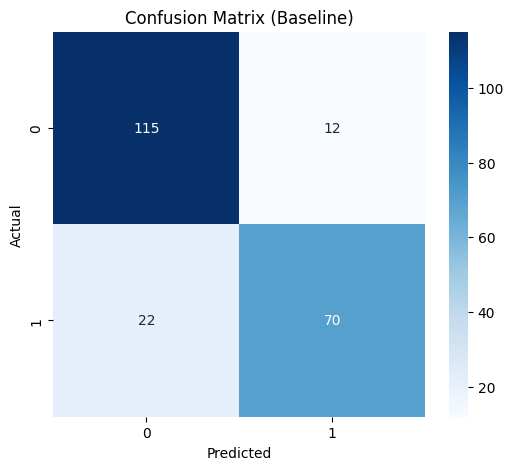


Detailed Classification Report (Baseline):
              precision    recall  f1-score   support

           0       0.84      0.91      0.87       127
           1       0.85      0.76      0.80        92

    accuracy                           0.84       219
   macro avg       0.85      0.83      0.84       219
weighted avg       0.85      0.84      0.84       219



In [25]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, recall_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.ensemble import RandomForestClassifier

# ==========================================
# 1. TRAIN BASELINE MODEL (Default Settings)
# ==========================================
# We use standard settings: n_estimators=100, no depth limits
print("⏳ Training Baseline Random Forest...")
rf_baseline = RandomForestClassifier(n_estimators=100, random_state=42)
rf_baseline.fit(X_train, y_train)

# ==========================================
# 2. EVALUATE BASELINE
# ==========================================
y_pred_base = rf_baseline.predict(X_test)
y_prob_base = rf_baseline.predict_proba(X_test)[:, 1]

# --- A. THE "BIG 4" METRICS TABLE ---
acc = accuracy_score(y_test, y_pred_base)
f1 = f1_score(y_test, y_pred_base)
recall = recall_score(y_test, y_pred_base)
auc = roc_auc_score(y_test, y_prob_base)

print("\n📊 BASELINE MODEL EVALUATION (Before Tuning)")
print(f"---------------------------------------")
print(f"1. Accuracy:  {acc:.2%}  (Baseline)")
print(f"2. F1-Score:  {f1:.4f}")
print(f"3. Recall:    {recall:.2%}  (Catching Defaulters)")
print(f"4. ROC-AUC:   {auc:.4f}")
print(f"---------------------------------------")

# --- B. VISUALIZATIONS ---
# Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred_base), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix (Baseline)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# --- C. DETAILED REPORT ---
print("\nDetailed Classification Report (Baseline):")
print(classification_report(y_test, y_pred_base))

Model Training - After Hypertuning

In [11]:
from sklearn.model_selection import GridSearchCV

# ==========================================
# 4. OPTIMIZED MODEL TRAINING (Hyperparameter Tuning)
# ==========================================
print("⏳ Starting Grid Search to find best parameters...")

# 1. Define the "Grid" of settings to test
param_grid = {
    'n_estimators': [100, 200],        # Try 100 and 200 trees
    'max_depth': [None, 10, 20],       # Try limiting depth to prevent overfitting
    'min_samples_split': [2, 5, 10],   # Minimum samples to split a node
    'min_samples_leaf': [1, 2, 4]      # Minimum samples at a leaf
}

# 2. Setup the Grid Search
# cv=3 means it splits data into 3 parts to cross-validate (very robust)
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=3,
    n_jobs=-1,  # Use all CPU cores
    scoring='accuracy',
    verbose=1
)

# 3. Train on all combinations
grid_search.fit(X_train, y_train)

# 4. Get the Winner
best_rf_model = grid_search.best_estimator_

print(f"✅ Best Parameters Found: {grid_search.best_params_}")
print(f"✅ Best Training Accuracy (CV): {grid_search.best_score_:.2%}")

# IMPORTANT: From now on, use 'best_rf_model' instead of 'rf_model'

⏳ Starting Grid Search to find best parameters...
Fitting 3 folds for each of 54 candidates, totalling 162 fits
✅ Best Parameters Found: {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 100}
✅ Best Training Accuracy (CV): 90.60%


Evaluation

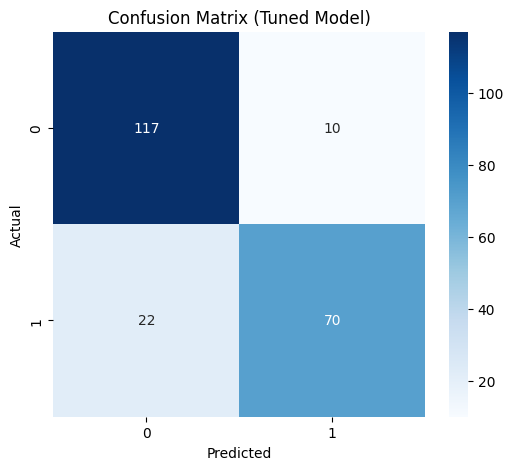


📊 FINAL MODEL EVALUATION (Tuned Random Forest)
---------------------------------------
1. Accuracy:  85.39%  (Overall correctness)
2. F1-Score:  0.8140  (Balance of Precision/Recall)
3. Recall:    76.09%  (How many defaulters we caught)
4. ROC-AUC:   0.8607  (Discrimination ability)
---------------------------------------

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.92      0.88       127
           1       0.88      0.76      0.81        92

    accuracy                           0.85       219
   macro avg       0.86      0.84      0.85       219
weighted avg       0.86      0.85      0.85       219



In [13]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, recall_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# ==========================================
# 5. EVALUATE THE TUNED MODEL
# ==========================================
# Use the optimized model (best_rf_model) for predictions
y_pred = best_rf_model.predict(X_test)
y_prob = best_rf_model.predict_proba(X_test)[:, 1]  # Probability needed for ROC-AUC

# --- A. VISUALIZATIONS ---
# 1. Confusion Matrix Heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix (Tuned Model)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# --- B. THE "BIG 4" METRICS TABLE ---
# Calculate metrics
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

print("\n📊 FINAL MODEL EVALUATION (Tuned Random Forest)")
print(f"---------------------------------------")
print(f"1. Accuracy:  {acc:.2%}  (Overall correctness)")
print(f"2. F1-Score:  {f1:.4f}  (Balance of Precision/Recall)")
print(f"3. Recall:    {recall:.2%}  (How many defaulters we caught)")
print(f"4. ROC-AUC:   {auc:.4f}  (Discrimination ability)")
print(f"---------------------------------------")

# --- C. DETAILED REPORT ---
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred))

Feature Importance

In [14]:
# Feature Importance
print("\n🏆 Top Predictors (Tuned):")
# We access feature_importances_ from the best estimator
print(pd.Series(best_rf_model.feature_importances_, index=X.columns).sort_values(ascending=False).head(5))


🏆 Top Predictors (Tuned):
DTI_Ratio        0.390437
Risk_Flag        0.289130
Loan_Amount      0.097824
Annual_Income    0.054992
Credit_Score     0.048020
dtype: float64


# **Part B: The LLM Analysis (The Insight)**
Use LLMs to summarise findings, provide insights, and interpret feature importance.

In [16]:
import google.generativeai as genai

# ==============================
# 1. CONFIGURE GEMINI
# ==============================
# Replace with your actual API key
from google.colab import userdata

api_key = userdata.get('GEMINI')
genai.configure(api_key=api_key)

# Note: As of early 2026, gemini-2.5-flash is a valid model name.
model_name = "gemini-2.5-flash"

/usr/local/lib/python3.12/dist-packages/google/colab/_import_hooks/_hook_injector.py:55: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  loader.exec_module(module)


In [22]:
# ==========================================
# 1. PREPARE DATA FOR PROMPT
# ==========================================
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd

# Calculate specific metrics for the Tuned Random Forest
y_pred = best_rf_model.predict(X_test)
y_prob = best_rf_model.predict_proba(X_test)[:, 1] # Probability needed for ROC-AUC

metrics = {
    'accuracy': accuracy_score(y_test, y_pred),
    'precision': precision_score(y_test, y_pred),
    'recall': recall_score(y_test, y_pred), # Critical for catching defaulters
    'f1': f1_score(y_test, y_pred),
    'roc_auc': roc_auc_score(y_test, y_prob)
}

# Extract Top 5 Features (Random Forest specific)
# Fix: Use X_train.columns (or X_test.columns) as the index
# because best_rf_model was trained on X_train after preprocessing (one-hot encoding).
importances = pd.Series(best_rf_model.feature_importances_, index=X_train.columns)
top_features = importances.sort_values(ascending=False).head(5)
top_features_str = "\n".join([f"- {name}: {score:.4f}" for name, score in top_features.items()])

# ==========================================
# 2. THE PROMPT
# ==========================================
prompt = f"""
You are a Senior Credit Risk Analyst and Data Science Consultant.
I have trained a Random Forest Classifier on a financial dataset to predict loan defaults.
Below are the actual performance metrics and the most important features identified by the model.

### 1. MODEL PERFORMANCE:
- Accuracy: {metrics['accuracy']:.2%}
- Precision: {metrics['precision']:.2%}
- Recall (Sensitivity): {metrics['recall']:.2%}
- F1-score: {metrics['f1']:.2%}
- ROC-AUC Score: {metrics['roc_auc']:.2%}

### 2. TOP PREDICTIVE FEATURES:
{top_features_str}

### YOUR TASK:
Please write a professional "Model Evaluation Report" covering the following:

1. **Executive Summary**: Is this model effective for risk management? (Focus on the trade-off between Precision and Recall).
2. **Feature Interpretation**: Explain *why* the top features listed above (e.g., DTI_Ratio, Risk_Flag) are physically predictive of a borrower defaulting. connect this to financial logic.
3. **Strategic Recommendations**: Based on these findings, what one specific action should the bank take to reduce defaults?
4. **Limitations**: Mention any potential risks of relying on a Random Forest (e.g., historical bias).

Format the response in a clear, structured, professional report style suitable for a bank executive.
"""

# Test: Print it to see how it looks
print(prompt)


You are a Senior Credit Risk Analyst and Data Science Consultant.
I have trained a Random Forest Classifier on a financial dataset to predict loan defaults.
Below are the actual performance metrics and the most important features identified by the model.

### 1. MODEL PERFORMANCE:
- Accuracy: 85.39%
- Precision: 87.50%
- Recall (Sensitivity): 76.09%
- F1-score: 81.40%
- ROC-AUC Score: 86.07%

### 2. TOP PREDICTIVE FEATURES:
- DTI_Ratio: 0.3904
- Risk_Flag: 0.2891
- Loan_Amount: 0.0978
- Annual_Income: 0.0550
- Credit_Score: 0.0480

### YOUR TASK:
Please write a professional "Model Evaluation Report" covering the following:

1. **Executive Summary**: Is this model effective for risk management? (Focus on the trade-off between Precision and Recall).
2. **Feature Interpretation**: Explain *why* the top features listed above (e.g., DTI_Ratio, Risk_Flag) are physically predictive of a borrower defaulting. connect this to financial logic.
3. **Strategic Recommendations**: Based on these fin

In [23]:
# In the google-generativeai library, we use GenerativeModel
model = genai.GenerativeModel(
    model_name=model_name,
    generation_config={
        "temperature": 0.2,
        "max_output_tokens": 10000,
    }
)


In [24]:
# ==========================================
# PART C: GENERATE WITH GEMINI
# ==========================================
print("🤖 Generating Analysis with Gemini...")

# Generation Config (Your settings were good!)
generation_config = {
    "max_output_tokens": 20000,  # 2k is plenty for a report (20k is overkill/safe)
    "temperature": 0.7,
}

# Generate
response = model.generate_content(prompt, generation_config=generation_config)

# ==========================================
# PART D: DISPLAY OUTPUT
# ==========================================
if response.text:
    print("\n" + "="*50)
    print("📝 GEMINI AUTOMATED FINDINGS")
    print("="*50)
    print(response.text)
else:
    print("No response received. Check safety settings.")

🤖 Generating Analysis with Gemini...

📝 GEMINI AUTOMATED FINDINGS
## Model Evaluation Report: Loan Default Prediction Model

**To:** Executive Leadership, Risk Management Committee
**From:** [Your Name/Department], Senior Credit Risk Analyst & Data Science Consultant
**Date:** October 26, 2023
**Subject:** Evaluation of Random Forest Classifier for Loan Default Prediction

---

### 1. Executive Summary

This report evaluates the performance of a recently trained Random Forest Classifier designed to predict loan defaults. The model demonstrates strong overall performance with an **Accuracy of 85.39%** and a **ROC-AUC Score of 86.07%**, indicating its general capability to distinguish between defaulting and non-defaulting borrowers.

A critical aspect for risk management is the trade-off between Precision and Recall for the positive class (loan default).
*   **Precision (87.50%)**: When the model predicts a loan will default, it is correct 87.50% of the time. This means the model is high